# CSE498R Research Project

## Notebook 02 — QUH Benchmark Preprocessing & Cache Construction

### Research Topic
**Long-Tail Logit Calibration (LTLC) for Hyperspectral Image Classification**

### Protocol
Experiment Blueprint v3.1 — Audited Public-Split Implementation

### Input
Frozen artifacts generated by:

`01_QUH_Data_Preflight_Integrity_Audit.ipynb`

---

## Purpose

This notebook reproduces the benchmark-compatible hyperspectral preprocessing pipeline:

1. load the immutable train/validation/test split artifacts from Notebook 01;
2. verify their SHA-256 fingerprints;
3. load one HSI cube at a time;
4. apply full-cube PCA;
5. apply row-wise min-max normalization across retained PCA components;
6. reshape the transformed pixels back to the spatial cube;
7. verify preprocessing numerically;
8. prepare zero-padded cubes for spectral-spatial patch extraction;
9. save reusable preprocessing caches for later HybridSN training.

> No model training, Logit Adjustment, LTLC tuning, or test-set model selection is performed in this notebook.

## Gate 2 — Benchmark Preprocessing Success Criteria

Notebook 02 passes only if:

- Notebook 01 metadata loads successfully.
- Frozen split files load successfully.
- Split SHA-256 fingerprints match Notebook 01.
- No new train/validation split is generated.
- Each HSI cube matches its audited spatial and spectral dimensions.
- PCA uses the locked number of components:
  - Pingan = 15
  - Qingyun = 15
  - Tangdaowan = 20
- PCA is fitted to the full unlabeled image cube.
- No class labels are passed to PCA.
- Row-wise min-max scaling is applied after PCA.
- Transformed values are finite.
- Non-constant transformed pixel vectors lie within `[0, 1]`.
- The transformed cube is reshaped to the correct spatial dimensions.
- Zero padding uses the dataset-specific patch radius.
- Frozen train/validation/test center indices remain unchanged.
- Preprocessed artifacts are saved and reload successfully.

If any mandatory check fails:

**STOP — do not begin HybridSN training.**

In [1]:
# ============================================================
# CELL 03 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
# ============================================================
# CELL 04 — IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import sys
import gc
import json
import time
import hashlib
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy.io import loadmat, whosmat

import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale

try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False

print("All Notebook 02 libraries imported successfully.")

All Notebook 02 libraries imported successfully.


In [3]:
# ============================================================
# CELL 05 — PROJECT DIRECTORY CONFIGURATION
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)

DATA_RAW_DIR = PROJECT_ROOT / "data_raw"
SPLIT_DIR = PROJECT_ROOT / "split_indices"
AUDIT_DIR = PROJECT_ROOT / "audit"
DATA_CACHE_DIR = PROJECT_ROOT / "data_cache"

PCA_CACHE_DIR = DATA_CACHE_DIR / "pca_normalized_cubes"
PREPROCESS_AUDIT_DIR = AUDIT_DIR / "notebook02_preprocessing"

PCA_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREPROCESS_AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 80)
print("NOTEBOOK 02 DIRECTORIES")
print("=" * 80)

print("Project root        :", PROJECT_ROOT)
print("Raw data            :", DATA_RAW_DIR)
print("Frozen splits       :", SPLIT_DIR)
print("Notebook 01 audit   :", AUDIT_DIR)
print("PCA cache           :", PCA_CACHE_DIR)
print("Preprocessing audit :", PREPROCESS_AUDIT_DIR)

print("=" * 80)

NOTEBOOK 02 DIRECTORIES
Project root        : /content/drive/MyDrive/CSE498/LTLC
Raw data            : /content/drive/MyDrive/CSE498/LTLC/data_raw
Frozen splits       : /content/drive/MyDrive/CSE498/LTLC/split_indices
Notebook 01 audit   : /content/drive/MyDrive/CSE498/LTLC/audit
PCA cache           : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes
Preprocessing audit : /content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing


In [4]:
# ============================================================
# CELL 06 — LOAD NOTEBOOK 01 PROTOCOL METADATA
# ============================================================

METADATA_PATH = (
    AUDIT_DIR /
    "notebook01_protocol_metadata.json"
)

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Notebook 01 metadata not found:\n{METADATA_PATH}"
    )

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8"
) as f:
    NOTEBOOK01_METADATA = json.load(f)


print("=" * 90)
print("NOTEBOOK 01 PROTOCOL METADATA LOADED")
print("=" * 90)

print(
    "Protocol version :",
    NOTEBOOK01_METADATA["protocol_version"]
)

print(
    "Validation seed  :",
    NOTEBOOK01_METADATA["validation_split_seed"]
)

print(
    "Validation frac. :",
    NOTEBOOK01_METADATA["validation_fraction"]
)

print(
    "Training seeds   :",
    NOTEBOOK01_METADATA["model_training_seeds"]
)

print("\nDatasets:")

for name, cfg in NOTEBOOK01_METADATA["datasets"].items():

    print(
        f"{name:12s} | "
        f"shape={tuple(cfg['cube_shape'])} | "
        f"eval classes={cfg['evaluation_class_count']} | "
        f"PCA={cfg['pca_components']} | "
        f"patch={cfg['patch_size']}"
    )

print("=" * 90)

NOTEBOOK 01 PROTOCOL METADATA LOADED
Protocol version : Experiment Blueprint v3.1 - audited public split
Validation seed  : 2026
Validation frac. : 0.3
Training seeds   : [42, 123, 3407]

Datasets:
Pingan       | shape=(1230, 1000, 176) | eval classes=10 | PCA=15 | patch=13
Qingyun      | shape=(880, 1360, 176) | eval classes=6 | PCA=15 | patch=11
Tangdaowan   | shape=(1740, 860, 176) | eval classes=16 | PCA=20 | patch=9


In [5]:
# ============================================================
# CELL 07 — BUILD NOTEBOOK 02 DATASET REGISTRY
# ============================================================

DATASETS = {
    "Pingan": {
        "folder": DATA_RAW_DIR / "Pingan",
        "cube_file": "QUH-Pingan.mat",
        "cube_key": "Haigang",
        "split_file": "pingan_fixed_split_seed2026.npz",
    },

    "Qingyun": {
        "folder": DATA_RAW_DIR / "Qingyun",
        "cube_file": "QUH-Qingyun.mat",
        "cube_key": "Chengqu",
        "split_file": "qingyun_fixed_split_seed2026.npz",
    },

    "Tangdaowan": {
        "folder": DATA_RAW_DIR / "Tangdaowan",
        "cube_file": "QUH-Tangdaowan.mat",
        "cube_key": "Tangdaowan",
        "split_file": "tangdaowan_fixed_split_seed2026.npz",
    },
}


for dataset_name, cfg in DATASETS.items():

    meta = NOTEBOOK01_METADATA[
        "datasets"
    ][dataset_name]

    cfg.update({
        "cube_shape":
            tuple(meta["cube_shape"]),

        "evaluation_classes":
            int(meta["evaluation_class_count"]),

        "evaluation_class_ids":
            [int(x) for x in meta["evaluation_class_ids"]],

        "pca_components":
            int(meta["pca_components"]),

        "patch_size":
            int(meta["patch_size"]),

        "expected_split_hash":
            meta["split_hashes"]["combined_split_hash"],
    })


print("=" * 90)
print("NOTEBOOK 02 DATASET REGISTRY")
print("=" * 90)

for dataset_name, cfg in DATASETS.items():

    print(f"\n{dataset_name}")

    print(
        "  HSI file      :",
        cfg["cube_file"]
    )

    print(
        "  HSI key       :",
        cfg["cube_key"]
    )

    print(
        "  Cube shape    :",
        cfg["cube_shape"]
    )

    print(
        "  Classes       :",
        cfg["evaluation_classes"]
    )

    print(
        "  PCA components:",
        cfg["pca_components"]
    )

    print(
        "  Patch size    :",
        cfg["patch_size"]
    )

    print(
        "  Split file    :",
        cfg["split_file"]
    )

NOTEBOOK 02 DATASET REGISTRY

Pingan
  HSI file      : QUH-Pingan.mat
  HSI key       : Haigang
  Cube shape    : (1230, 1000, 176)
  Classes       : 10
  PCA components: 15
  Patch size    : 13
  Split file    : pingan_fixed_split_seed2026.npz

Qingyun
  HSI file      : QUH-Qingyun.mat
  HSI key       : Chengqu
  Cube shape    : (880, 1360, 176)
  Classes       : 6
  PCA components: 15
  Patch size    : 11
  Split file    : qingyun_fixed_split_seed2026.npz

Tangdaowan
  HSI file      : QUH-Tangdaowan.mat
  HSI key       : Tangdaowan
  Cube shape    : (1740, 860, 176)
  Classes       : 16
  PCA components: 20
  Patch size    : 9
  Split file    : tangdaowan_fixed_split_seed2026.npz


In [6]:
# ============================================================
# CELL 08 — RUNTIME MEMORY INFORMATION
# ============================================================

print("=" * 80)
print("COLAB RUNTIME MEMORY")
print("=" * 80)

if PSUTIL_AVAILABLE:

    memory = psutil.virtual_memory()

    total_gb = memory.total / (1024 ** 3)
    available_gb = memory.available / (1024 ** 3)

    print(
        f"Total system RAM     : {total_gb:.2f} GB"
    )

    print(
        f"Currently available  : {available_gb:.2f} GB"
    )

else:

    print(
        "psutil unavailable; memory information skipped."
    )

print("=" * 80)

print(
    "\nImportant: Notebook 02 will process "
    "ONE HSI dataset at a time."
)

COLAB RUNTIME MEMORY
Total system RAM     : 12.67 GB
Currently available  : 11.36 GB

Important: Notebook 02 will process ONE HSI dataset at a time.


In [7]:
# ============================================================
# CELL 09 — VERIFY FROZEN NOTEBOOK 01 SPLIT ARTIFACTS
# ============================================================

def sha256_array(array):

    array = np.ascontiguousarray(array)

    hasher = hashlib.sha256()

    hasher.update(
        str(array.shape).encode("utf-8")
    )

    hasher.update(
        str(array.dtype).encode("utf-8")
    )

    hasher.update(
        array.tobytes()
    )

    return hasher.hexdigest()


FROZEN_SPLITS = {}
split_verification_results = {}

print("=" * 95)
print("NOTEBOOK 01 FROZEN-SPLIT VERIFICATION")
print("=" * 95)

for dataset_name, cfg in DATASETS.items():

    split_path = (
        SPLIT_DIR /
        cfg["split_file"]
    )

    if not split_path.exists():

        raise FileNotFoundError(
            f"{dataset_name}: split file missing:\n"
            f"{split_path}"
        )

    with np.load(
        split_path,
        allow_pickle=False
    ) as saved:

        split = {
            key: saved[key].copy()
            for key in saved.files
        }

    # --------------------------------------------------------
    # Recompute combined SHA-256 fingerprint
    # --------------------------------------------------------

    train_hash = sha256_array(
        split["train_indices"]
    )

    val_hash = sha256_array(
        split["val_indices"]
    )

    test_hash = sha256_array(
        split["test_indices"]
    )

    combined_hasher = hashlib.sha256()

    combined_hasher.update(
        train_hash.encode("utf-8")
    )

    combined_hasher.update(
        val_hash.encode("utf-8")
    )

    combined_hasher.update(
        test_hash.encode("utf-8")
    )

    observed_hash = (
        combined_hasher.hexdigest()
    )

    expected_hash = (
        cfg["expected_split_hash"]
    )

    hash_pass = (
        observed_hash == expected_hash
    )

    # --------------------------------------------------------
    # Verify frozen protocol fields
    # --------------------------------------------------------

    saved_seed = int(
        split["validation_split_seed"][0]
    )

    saved_fraction = float(
        split["validation_fraction"][0]
    )

    saved_shape = tuple(
        split["spatial_shape"].tolist()
    )

    saved_bands = int(
        split["spectral_bands"][0]
    )

    seed_pass = (
        saved_seed
        ==
        NOTEBOOK01_METADATA[
            "validation_split_seed"
        ]
    )

    fraction_pass = np.isclose(
        saved_fraction,
        NOTEBOOK01_METADATA[
            "validation_fraction"
        ]
    )

    shape_pass = (
        saved_shape
        ==
        cfg["cube_shape"][:2]
    )

    bands_pass = (
        saved_bands
        ==
        cfg["cube_shape"][2]
    )

    overall_pass = all([
        hash_pass,
        seed_pass,
        fraction_pass,
        shape_pass,
        bands_pass,
    ])

    FROZEN_SPLITS[
        dataset_name
    ] = split

    split_verification_results[
        dataset_name
    ] = overall_pass

    print(f"\n{dataset_name.upper()}")
    print("-" * 72)

    print(
        "Split SHA-256      :",
        "PASS" if hash_pass else "FAIL"
    )

    print(
        "Validation seed    :",
        "PASS" if seed_pass else "FAIL",
        f"({saved_seed})"
    )

    print(
        "Validation fraction:",
        "PASS" if fraction_pass else "FAIL",
        f"({saved_fraction})"
    )

    print(
        "Spatial shape      :",
        "PASS" if shape_pass else "FAIL",
        saved_shape
    )

    print(
        "Spectral bands     :",
        "PASS" if bands_pass else "FAIL",
        saved_bands
    )

    print(
        "STATUS             :",
        "PASS" if overall_pass else "FAIL"
    )


print("\n" + "=" * 95)

ALL_FROZEN_SPLITS_VALID = all(
    split_verification_results.values()
)

print(
    "FROZEN SPLIT GATE:",
    "PASS" if ALL_FROZEN_SPLITS_VALID else "FAIL"
)

print("=" * 95)

NOTEBOOK 01 FROZEN-SPLIT VERIFICATION

PINGAN
------------------------------------------------------------------------
Split SHA-256      : PASS
Validation seed    : PASS (2026)
Validation fraction: PASS (0.3)
Spatial shape      : PASS (1230, 1000)
Spectral bands     : PASS 176
STATUS             : PASS

QINGYUN
------------------------------------------------------------------------
Split SHA-256      : PASS
Validation seed    : PASS (2026)
Validation fraction: PASS (0.3)
Spatial shape      : PASS (880, 1360)
Spectral bands     : PASS 176
STATUS             : PASS

TANGDAOWAN
------------------------------------------------------------------------
Split SHA-256      : PASS
Validation seed    : PASS (2026)
Validation fraction: PASS (0.3)
Spatial shape      : PASS (1740, 860)
Spectral bands     : PASS 176
STATUS             : PASS

FROZEN SPLIT GATE: PASS


## Benchmark-Compatible PCA Preprocessing Lock

The main preprocessing follows the reference ConvVitMamba implementation.

For each dataset:

1. Load the complete unlabeled hyperspectral cube.
2. Reshape it from `[H, W, Bands]` to `[H × W, Bands]`.
3. Fit PCA on the complete unlabeled cube.
4. Retain the dataset-specific number of components.
5. Apply row-wise min-max scaling across the retained PCA components.
6. Reshape the transformed data back to `[H, W, PCA_components]`.
7. Apply zero padding only after PCA and normalization.

### Locked PCA configuration

- `PCA(n_components=N)`
- no whitening;
- no label information;
- no training-mask filtering during PCA;
- default scikit-learn PCA behavior otherwise.

### Locked component counts

- Pingan: 15
- Qingyun: 15
- Tangdaowan: 20

The main experiment therefore uses transductive unsupervised preprocessing:
test spectra contribute to PCA fitting, but test labels never do.

In [8]:
# ============================================================
# CELL 11 — ADDITIONAL UTILITIES
# ============================================================

import shutil
import joblib


LOCAL_WORK_DIR = Path("/content/ltlc_notebook02")
LOCAL_WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def print_memory_status(label="Memory"):

    if not PSUTIL_AVAILABLE:
        print(f"{label}: psutil unavailable")
        return

    memory = psutil.virtual_memory()

    total_gb = memory.total / (1024 ** 3)
    available_gb = memory.available / (1024 ** 3)
    used_gb = memory.used / (1024 ** 3)

    print(
        f"{label:25s} | "
        f"Used: {used_gb:6.2f} GB | "
        f"Available: {available_gb:6.2f} GB | "
        f"Total: {total_gb:6.2f} GB"
    )


print("Notebook 02 utility functions created.")
print_memory_status("Current runtime")

Notebook 02 utility functions created.
Current runtime           | Used:   1.08 GB | Available:  11.31 GB | Total:  12.67 GB


In [9]:
# ============================================================
# CELL 12 — SAFE ONE-DATASET HSI LOADER
# ============================================================

def load_hsi_cube(dataset_name, use_local_copy=True):
    """
    Load ONE hyperspectral cube at a time.

    Optionally copies the .mat file from Google Drive to
    Colab's local disk first for faster repeated local access.
    """

    if dataset_name not in DATASETS:
        raise ValueError(
            f"Unknown dataset: {dataset_name}"
        )

    cfg = DATASETS[dataset_name]

    drive_path = (
        cfg["folder"] /
        cfg["cube_file"]
    )

    if not drive_path.exists():
        raise FileNotFoundError(
            f"HSI cube not found:\n{drive_path}"
        )

    # --------------------------------------------------------
    # Optional temporary local copy
    # --------------------------------------------------------

    if use_local_copy:

        local_path = (
            LOCAL_WORK_DIR /
            cfg["cube_file"]
        )

        if not local_path.exists():

            print(
                f"Copying {cfg['cube_file']} "
                f"from Drive to local Colab storage..."
            )

            shutil.copy2(
                drive_path,
                local_path
            )

            print("Local copy complete.")

        load_path = local_path

    else:

        load_path = drive_path

    # --------------------------------------------------------
    # Load only the verified HSI variable
    # --------------------------------------------------------

    print(
        f"Loading {dataset_name} HSI cube..."
    )

    start_time = time.time()

    mat_data = loadmat(
        str(load_path),
        variable_names=[
            cfg["cube_key"]
        ]
    )

    cube = mat_data[
        cfg["cube_key"]
    ]

    del mat_data
    gc.collect()

    elapsed = time.time() - start_time

    print(
        f"Loaded successfully in "
        f"{elapsed:.2f} seconds."
    )

    return cube, load_path


print("Safe one-dataset HSI loader created.")

Safe one-dataset HSI loader created.


In [10]:
# ============================================================
# CELL 13 — LOAD PINGAN HSI CUBE
# ============================================================

CURRENT_DATASET = "Pingan"

print("=" * 90)
print("PINGAN — RAW HSI LOAD")
print("=" * 90)

print_memory_status(
    "Before Pingan load"
)

pingan_cube, pingan_local_path = (
    load_hsi_cube(
        CURRENT_DATASET,
        use_local_copy=True
    )
)

print()
print("Loaded cube shape :", pingan_cube.shape)
print("Loaded cube dtype :", pingan_cube.dtype)

print(
    "Cube RAM size     : "
    f"{pingan_cube.nbytes / (1024 ** 3):.2f} GB"
)

print(
    "Expected shape    :",
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)

shape_pass = (
    tuple(pingan_cube.shape)
    ==
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)

finite_pass = np.isfinite(
    pingan_cube
).all()

print()
print(
    "Shape check       :",
    "PASS" if shape_pass else "FAIL"
)

print(
    "Finite values     :",
    "PASS" if finite_pass else "FAIL"
)

print_memory_status(
    "After Pingan load"
)

if not (
    shape_pass
    and finite_pass
):
    raise ValueError(
        "Pingan raw-cube validation failed."
    )

PINGAN — RAW HSI LOAD
Before Pingan load        | Used:   1.08 GB | Available:  11.32 GB | Total:  12.67 GB
Copying QUH-Pingan.mat from Drive to local Colab storage...
Local copy complete.
Loading Pingan HSI cube...
Loaded successfully in 16.92 seconds.

Loaded cube shape : (1230, 1000, 176)
Loaded cube dtype : float64
Cube RAM size     : 1.61 GB
Expected shape    : (1230, 1000, 176)

Shape check       : PASS
Finite values     : PASS
After Pingan load         | Used:   2.96 GB | Available:   9.41 GB | Total:  12.67 GB


In [11]:
# ============================================================
# CELL 14 — EXACT REFERENCE PCA + NORMALIZATION FUNCTION
# ============================================================

def apply_reference_pca_normalization(
    cube,
    n_components
):
    """
    Reproduce ConvVitMamba utils.py::applyPCA:

        reshape full cube
        PCA(n_components=N)
        fit_transform
        minmax_scale(axis=1)
        reshape back

    No labels are accepted by this function.
    """

    if cube.ndim != 3:
        raise ValueError(
            "HSI cube must have shape [H, W, Bands]."
        )

    H, W, B = cube.shape

    print("=" * 90)
    print("REFERENCE PCA + NORMALIZATION")
    print("=" * 90)

    print(
        f"Input cube       : {cube.shape}"
    )

    print(
        f"PCA components   : {n_components}"
    )

    print(
        "PCA whitening    : False"
    )

    print(
        "PCA input labels : NONE"
    )

    print_memory_status(
        "Before PCA"
    )

    # --------------------------------------------------------
    # 1. Reshape complete cube
    # --------------------------------------------------------

    flat_cube = np.reshape(
        cube,
        (-1, B)
    )

    print(
        f"\nFlattened shape  : {flat_cube.shape}"
    )

    # --------------------------------------------------------
    # 2. Reference PCA
    # --------------------------------------------------------

    pca = PCA(
        n_components=n_components
    )

    pca_start = time.time()

    pca_scores = pca.fit_transform(
        flat_cube
    )

    pca_elapsed = (
        time.time() - pca_start
    )

    print(
        f"PCA output shape : {pca_scores.shape}"
    )

    print(
        f"PCA elapsed      : {pca_elapsed:.2f} sec"
    )

    print(
        f"PCA solver used  : "
        f"{getattr(pca, '_fit_svd_solver', 'unknown')}"
    )

    print_memory_status(
        "After PCA"
    )

    # --------------------------------------------------------
    # Release the raw cube before normalization when possible.
    # flat_cube is only a view of cube.
    # --------------------------------------------------------

    del flat_cube
    gc.collect()

    # --------------------------------------------------------
    # 3. Exact reference normalization
    # --------------------------------------------------------

    norm_start = time.time()

    normalized_flat = minmax_scale(
        pca_scores,
        axis=1
    )

    norm_elapsed = (
        time.time() - norm_start
    )

    print(
        f"Normalization    : "
        f"minmax_scale(axis=1)"
    )

    print(
        f"Norm elapsed     : {norm_elapsed:.2f} sec"
    )

    # PCA scores are no longer needed.
    del pca_scores
    gc.collect()

    # --------------------------------------------------------
    # 4. Reshape back to cube
    # --------------------------------------------------------

    normalized_cube = np.reshape(
        normalized_flat,
        (H, W, n_components)
    )

    del normalized_flat
    gc.collect()

    print(
        f"Final cube shape : "
        f"{normalized_cube.shape}"
    )

    print_memory_status(
        "After normalization"
    )

    return (
        normalized_cube,
        pca,
        {
            "pca_elapsed_sec":
                pca_elapsed,

            "normalization_elapsed_sec":
                norm_elapsed,

            "pca_solver":
                getattr(
                    pca,
                    "_fit_svd_solver",
                    "unknown"
                ),
        }
    )


print(
    "Exact benchmark preprocessing "
    "function created successfully."
)

Exact benchmark preprocessing function created successfully.


In [12]:
# ============================================================
# CELL 15 — RUN PINGAN PCA + ROW-WISE MIN-MAX NORMALIZATION
# ============================================================

PINGAN_PCA_COMPONENTS = DATASETS[
    "Pingan"
]["pca_components"]

print("=" * 90)
print("PINGAN — BENCHMARK PREPROCESSING")
print("=" * 90)

pingan_preprocessed, pingan_pca, pingan_timing = (
    apply_reference_pca_normalization(
        cube=pingan_cube,
        n_components=PINGAN_PCA_COMPONENTS
    )
)

print()
print("Pingan preprocessing complete.")

PINGAN — BENCHMARK PREPROCESSING
REFERENCE PCA + NORMALIZATION
Input cube       : (1230, 1000, 176)
PCA components   : 15
PCA whitening    : False
PCA input labels : NONE
Before PCA                | Used:   3.04 GB | Available:   9.33 GB | Total:  12.67 GB

Flattened shape  : (1230000, 176)
PCA output shape : (1230000, 15)
PCA elapsed      : 2.89 sec
PCA solver used  : covariance_eigh
After PCA                 | Used:   4.83 GB | Available:   7.54 GB | Total:  12.67 GB
Normalization    : minmax_scale(axis=1)
Norm elapsed     : 0.38 sec
Final cube shape : (1230, 1000, 15)
After normalization       | Used:   3.27 GB | Available:   9.10 GB | Total:  12.67 GB

Pingan preprocessing complete.


In [13]:
# ============================================================
# CELL 16 — PINGAN PREPROCESSING INTEGRITY AUDIT
# ============================================================

print("=" * 95)
print("PINGAN — PCA/NORMALIZATION INTEGRITY AUDIT")
print("=" * 95)

expected_shape = (
    DATASETS["Pingan"]["cube_shape"][0],
    DATASETS["Pingan"]["cube_shape"][1],
    DATASETS["Pingan"]["pca_components"],
)

shape_pass = (
    pingan_preprocessed.shape
    ==
    expected_shape
)

finite_pass = np.isfinite(
    pingan_preprocessed
).all()

global_min = float(
    np.min(pingan_preprocessed)
)

global_max = float(
    np.max(pingan_preprocessed)
)

range_pass = (
    global_min >= -1e-12
    and
    global_max <= 1.0 + 1e-12
)

# ------------------------------------------------------------
# Validate per-pixel row-wise normalization
# ------------------------------------------------------------

flat_norm = pingan_preprocessed.reshape(
    -1,
    pingan_preprocessed.shape[-1]
)

row_min = flat_norm.min(
    axis=1
)

row_max = flat_norm.max(
    axis=1
)

row_range = row_max - row_min

nonconstant_rows = (
    row_range > 1e-12
)

nonconstant_count = int(
    nonconstant_rows.sum()
)

constant_count = int(
    len(row_range)
    -
    nonconstant_count
)

if nonconstant_count > 0:

    row_min_pass = np.allclose(
        row_min[nonconstant_rows],
        0.0,
        atol=1e-10
    )

    row_max_pass = np.allclose(
        row_max[nonconstant_rows],
        1.0,
        atol=1e-10
    )

else:

    row_min_pass = True
    row_max_pass = True


# ------------------------------------------------------------
# PCA object checks
# ------------------------------------------------------------

component_pass = (
    pingan_pca.n_components_
    ==
    PINGAN_PCA_COMPONENTS
)

whiten_pass = (
    pingan_pca.whiten is False
)

explained_variance_sum = float(
    np.sum(
        pingan_pca.explained_variance_ratio_
    )
)

overall_pass = all([
    shape_pass,
    finite_pass,
    range_pass,
    row_min_pass,
    row_max_pass,
    component_pass,
    whiten_pass,
])


print(
    "Output shape              :",
    pingan_preprocessed.shape
)

print(
    "Expected shape            :",
    expected_shape
)

print(
    "Shape                     :",
    "PASS" if shape_pass else "FAIL"
)

print()

print(
    f"Global minimum            : "
    f"{global_min:.12f}"
)

print(
    f"Global maximum            : "
    f"{global_max:.12f}"
)

print(
    "All values finite         :",
    "PASS" if finite_pass else "FAIL"
)

print(
    "Values within [0,1]       :",
    "PASS" if range_pass else "FAIL"
)

print()

print(
    "Non-constant pixel rows   :",
    nonconstant_count
)

print(
    "Constant pixel rows       :",
    constant_count
)

print(
    "Nonconstant row min = 0   :",
    "PASS" if row_min_pass else "FAIL"
)

print(
    "Nonconstant row max = 1   :",
    "PASS" if row_max_pass else "FAIL"
)

print()

print(
    "PCA components            :",
    pingan_pca.n_components_
)

print(
    "Component-count check     :",
    "PASS" if component_pass else "FAIL"
)

print(
    "PCA whitening disabled    :",
    "PASS" if whiten_pass else "FAIL"
)

print(
    f"Explained variance retained: "
    f"{explained_variance_sum:.6f}"
)

print(
    "PCA solver                :",
    pingan_timing["pca_solver"]
)

print()

print(
    "PINGAN PREPROCESSING STATUS:",
    "PASS" if overall_pass else "FAIL"
)

print("=" * 95)

PINGAN_PREPROCESSING_PASS = overall_pass

# Cleanup temporary audit arrays
del flat_norm
del row_min
del row_max
del row_range
del nonconstant_rows

gc.collect()

PINGAN — PCA/NORMALIZATION INTEGRITY AUDIT
Output shape              : (1230, 1000, 15)
Expected shape            : (1230, 1000, 15)
Shape                     : PASS

Global minimum            : 0.000000000000
Global maximum            : 1.000000000000
All values finite         : PASS
Values within [0,1]       : PASS

Non-constant pixel rows   : 1230000
Constant pixel rows       : 0
Nonconstant row min = 0   : PASS
Nonconstant row max = 1   : PASS

PCA components            : 15
Component-count check     : PASS
PCA whitening disabled    : PASS
Explained variance retained: 0.999918
PCA solver                : covariance_eigh

PINGAN PREPROCESSING STATUS: PASS


0

## Pingan Preprocessing Cache

The verified Pingan preprocessing output will now be frozen for later notebooks.

The canonical cache stores:

- PCA-normalized cube;
- fitted PCA model;
- preprocessing metadata;
- SHA-256 checksum.

The normalized cube is stored as `float32` because later PyTorch training uses
single-precision tensors. The PCA computation itself was performed using the
reference preprocessing pipeline before this storage conversion.

After the saved cache is verified, the raw Pingan cube and preprocessing arrays
will be removed from RAM before processing the next dataset.

In [14]:
# ============================================================
# CELL 18 — SAVE VERIFIED PINGAN PREPROCESSING CACHE
# ============================================================

if not PINGAN_PREPROCESSING_PASS:
    raise RuntimeError(
        "Pingan preprocessing did not pass. Cache creation blocked."
    )

PINGAN_CACHE_PATH = (
    PCA_CACHE_DIR /
    "pingan_pca15_rowminmax_float32.npy"
)

PINGAN_PCA_MODEL_PATH = (
    PCA_CACHE_DIR /
    "pingan_pca15_model.joblib"
)

PINGAN_METADATA_PATH = (
    PREPROCESS_AUDIT_DIR /
    "pingan_preprocessing_metadata.json"
)

# ------------------------------------------------------------
# Convert verified reference output to training precision
# ------------------------------------------------------------

pingan_cache_array = pingan_preprocessed.astype(
    np.float32,
    copy=False
)

# ------------------------------------------------------------
# Save normalized cube
# ------------------------------------------------------------

np.save(
    PINGAN_CACHE_PATH,
    pingan_cache_array,
    allow_pickle=False
)

# ------------------------------------------------------------
# Save fitted PCA object
# ------------------------------------------------------------

joblib.dump(
    pingan_pca,
    PINGAN_PCA_MODEL_PATH
)

print("=" * 90)
print("PINGAN CACHE SAVED")
print("=" * 90)

print("Cube cache :", PINGAN_CACHE_PATH)
print("PCA model  :", PINGAN_PCA_MODEL_PATH)

print(
    "Cache dtype:",
    pingan_cache_array.dtype
)

print(
    "Cache shape:",
    pingan_cache_array.shape
)

print(
    "Cache size : "
    f"{PINGAN_CACHE_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

PINGAN CACHE SAVED
Cube cache : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/pingan_pca15_rowminmax_float32.npy
PCA model  : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/pingan_pca15_model.joblib
Cache dtype: float32
Cache shape: (1230, 1000, 15)
Cache size : 70.38 MB


In [15]:
# ============================================================
# CELL 19 — SHA-256 HASH OF SAVED PINGAN CACHE
# ============================================================

def sha256_file(file_path, chunk_size=1024 * 1024):
    """
    Compute SHA-256 checksum of a file without loading the
    entire file into RAM.
    """

    hasher = hashlib.sha256()

    with open(file_path, "rb") as f:

        while True:

            chunk = f.read(chunk_size)

            if not chunk:
                break

            hasher.update(chunk)

    return hasher.hexdigest()


PINGAN_CACHE_SHA256 = sha256_file(
    PINGAN_CACHE_PATH
)

PINGAN_PCA_MODEL_SHA256 = sha256_file(
    PINGAN_PCA_MODEL_PATH
)

print("=" * 90)
print("PINGAN CACHE FINGERPRINTS")
print("=" * 90)

print(
    "Normalized cube SHA-256 :",
    PINGAN_CACHE_SHA256
)

print(
    "PCA model SHA-256       :",
    PINGAN_PCA_MODEL_SHA256
)

PINGAN CACHE FINGERPRINTS
Normalized cube SHA-256 : 857ffcb8f1a3837f19b7eba350c8a3c15f99d9e7dbede3a84b46249191f27daa
PCA model SHA-256       : ccfea6551ed03cbac12f9991da074147241dd8d862b340379cae2654484fb69f


In [16]:
# ============================================================
# CELL 20 — SAVE PINGAN PREPROCESSING METADATA
# ============================================================

pingan_preprocessing_metadata = {

    "dataset": "Pingan",

    "raw_cube_file":
        DATASETS["Pingan"]["cube_file"],

    "raw_cube_key":
        DATASETS["Pingan"]["cube_key"],

    "raw_cube_shape":
        list(DATASETS["Pingan"]["cube_shape"]),

    "raw_spectral_bands":
        int(DATASETS["Pingan"]["cube_shape"][2]),

    "pca_components":
        int(PINGAN_PCA_COMPONENTS),

    "pca_whiten":
        bool(pingan_pca.whiten),

    "pca_solver_selected":
        str(pingan_timing["pca_solver"]),

    "explained_variance_retained":
        float(
            np.sum(
                pingan_pca.explained_variance_ratio_
            )
        ),

    "normalization":
        "sklearn.preprocessing.minmax_scale(axis=1)",

    "pca_fit_scope":
        "full unlabeled image cube",

    "label_information_used_for_pca":
        False,

    "cache_shape":
        list(pingan_cache_array.shape),

    "cache_dtype":
        str(pingan_cache_array.dtype),

    "cache_file":
        PINGAN_CACHE_PATH.name,

    "cache_sha256":
        PINGAN_CACHE_SHA256,

    "pca_model_file":
        PINGAN_PCA_MODEL_PATH.name,

    "pca_model_sha256":
        PINGAN_PCA_MODEL_SHA256,

    "split_sha256":
        DATASETS["Pingan"]["expected_split_hash"],

    "pca_elapsed_sec":
        float(
            pingan_timing["pca_elapsed_sec"]
        ),

    "normalization_elapsed_sec":
        float(
            pingan_timing[
                "normalization_elapsed_sec"
            ]
        ),

    "created_at":
        datetime.now().isoformat(),
}


with open(
    PINGAN_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pingan_preprocessing_metadata,
        f,
        indent=2
    )


print(
    "Pingan preprocessing metadata saved:"
)

print(
    PINGAN_METADATA_PATH
)

Pingan preprocessing metadata saved:
/content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/pingan_preprocessing_metadata.json


In [17]:
# ============================================================
# CELL 21 — RELOAD AND VERIFY SAVED PINGAN CACHE
# ============================================================

print("=" * 95)
print("PINGAN SAVED-CACHE RELOAD AUDIT")
print("=" * 95)

# Memory-map saved array instead of reading another full copy
pingan_reloaded = np.load(
    PINGAN_CACHE_PATH,
    mmap_mode="r",
    allow_pickle=False
)

shape_pass = (
    pingan_reloaded.shape
    ==
    (
        1230,
        1000,
        15
    )
)

dtype_pass = (
    pingan_reloaded.dtype
    ==
    np.float32
)

finite_pass = np.isfinite(
    pingan_reloaded
).all()

min_value = float(
    np.min(pingan_reloaded)
)

max_value = float(
    np.max(pingan_reloaded)
)

range_pass = (
    min_value >= -1e-7
    and
    max_value <= 1.0 + 1e-7
)

# Compare saved float32 cache against current reference output
reference_float32 = pingan_preprocessed.astype(
    np.float32,
    copy=False
)

value_pass = np.array_equal(
    np.asarray(pingan_reloaded),
    reference_float32
)

reloaded_hash = sha256_file(
    PINGAN_CACHE_PATH
)

hash_pass = (
    reloaded_hash
    ==
    PINGAN_CACHE_SHA256
)

PINGAN_CACHE_RELOAD_PASS = all([
    shape_pass,
    dtype_pass,
    finite_pass,
    range_pass,
    value_pass,
    hash_pass,
])


print(
    "Shape                  :",
    "PASS" if shape_pass else "FAIL",
    pingan_reloaded.shape
)

print(
    "Dtype                  :",
    "PASS" if dtype_pass else "FAIL",
    pingan_reloaded.dtype
)

print(
    "Finite values          :",
    "PASS" if finite_pass else "FAIL"
)

print(
    f"Saved global range     : "
    f"[{min_value:.8f}, {max_value:.8f}]"
)

print(
    "Range within [0,1]     :",
    "PASS" if range_pass else "FAIL"
)

print(
    "Saved values identical :",
    "PASS" if value_pass else "FAIL"
)

print(
    "SHA-256 unchanged      :",
    "PASS" if hash_pass else "FAIL"
)

print()

print(
    "PINGAN CACHE STATUS    :",
    "PASS"
    if PINGAN_CACHE_RELOAD_PASS
    else "FAIL"
)

print("=" * 95)

PINGAN SAVED-CACHE RELOAD AUDIT
Shape                  : PASS (1230, 1000, 15)
Dtype                  : PASS float32
Finite values          : PASS
Saved global range     : [0.00000000, 1.00000000]
Range within [0,1]     : PASS
Saved values identical : PASS
SHA-256 unchanged      : PASS

PINGAN CACHE STATUS    : PASS


In [18]:
# ============================================================
# CELL 22 — RELEASE PINGAN ARRAYS FROM RAM
# ============================================================

if not PINGAN_CACHE_RELOAD_PASS:
    raise RuntimeError(
        "Saved Pingan cache did not pass reload verification."
    )

print_memory_status(
    "Before cleanup"
)

# Close/remove memory-mapped reference
del pingan_reloaded

# Remove heavy arrays
del pingan_cube
del pingan_preprocessed
del pingan_cache_array
del reference_float32

# PCA object no longer needed in RAM
del pingan_pca

gc.collect()

print_memory_status(
    "After cleanup"
)

print()
print(
    "Pingan has been safely cached and "
    "released from active RAM."
)

Before cleanup            | Used:   3.31 GB | Available:   9.06 GB | Total:  12.67 GB
After cleanup             | Used:   1.43 GB | Available:  10.93 GB | Total:  12.67 GB

Pingan has been safely cached and released from active RAM.


In [19]:
# ============================================================
# CELL 23 — DELETE TEMPORARY LOCAL PINGAN RAW FILE
# ============================================================

if Path(pingan_local_path).exists():

    Path(pingan_local_path).unlink()

    print(
        "Temporary local Pingan .mat file deleted."
    )

else:

    print(
        "No temporary local Pingan file found."
    )

print(
    "Master Google Drive copy remains untouched."
)

Temporary local Pingan .mat file deleted.
Master Google Drive copy remains untouched.


In [20]:
# ============================================================
# CELL 24 — REUSABLE PREPROCESSING AUDIT FUNCTION
# ============================================================

def audit_preprocessed_cube(
    dataset_name,
    preprocessed_cube,
    fitted_pca,
    timing_info
):
    """
    Validate a PCA + row-wise min-max normalized HSI cube.
    """

    cfg = DATASETS[dataset_name]

    expected_shape = (
        cfg["cube_shape"][0],
        cfg["cube_shape"][1],
        cfg["pca_components"],
    )

    # --------------------------------------------------------
    # Shape / finite / range
    # --------------------------------------------------------

    shape_pass = (
        preprocessed_cube.shape
        ==
        expected_shape
    )

    finite_pass = np.isfinite(
        preprocessed_cube
    ).all()

    global_min = float(
        np.min(preprocessed_cube)
    )

    global_max = float(
        np.max(preprocessed_cube)
    )

    range_pass = (
        global_min >= -1e-12
        and
        global_max <= 1.0 + 1e-12
    )

    # --------------------------------------------------------
    # Row-wise normalization audit
    # --------------------------------------------------------

    flat_norm = preprocessed_cube.reshape(
        -1,
        preprocessed_cube.shape[-1]
    )

    row_min = flat_norm.min(axis=1)
    row_max = flat_norm.max(axis=1)

    row_range = (
        row_max - row_min
    )

    nonconstant_rows = (
        row_range > 1e-12
    )

    nonconstant_count = int(
        nonconstant_rows.sum()
    )

    constant_count = int(
        len(row_range)
        -
        nonconstant_count
    )

    if nonconstant_count > 0:

        row_min_pass = np.allclose(
            row_min[nonconstant_rows],
            0.0,
            atol=1e-10
        )

        row_max_pass = np.allclose(
            row_max[nonconstant_rows],
            1.0,
            atol=1e-10
        )

    else:

        row_min_pass = True
        row_max_pass = True

    # --------------------------------------------------------
    # PCA audit
    # --------------------------------------------------------

    component_pass = (
        fitted_pca.n_components_
        ==
        cfg["pca_components"]
    )

    whiten_pass = (
        fitted_pca.whiten is False
    )

    explained_variance_sum = float(
        np.sum(
            fitted_pca.explained_variance_ratio_
        )
    )

    overall_pass = all([
        shape_pass,
        finite_pass,
        range_pass,
        row_min_pass,
        row_max_pass,
        component_pass,
        whiten_pass,
    ])

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    print("=" * 95)
    print(
        f"{dataset_name.upper()} — "
        f"PCA/NORMALIZATION INTEGRITY AUDIT"
    )
    print("=" * 95)

    print(
        "Output shape              :",
        preprocessed_cube.shape
    )

    print(
        "Expected shape            :",
        expected_shape
    )

    print(
        "Shape                     :",
        "PASS" if shape_pass else "FAIL"
    )

    print()

    print(
        f"Global minimum            : "
        f"{global_min:.12f}"
    )

    print(
        f"Global maximum            : "
        f"{global_max:.12f}"
    )

    print(
        "All values finite         :",
        "PASS" if finite_pass else "FAIL"
    )

    print(
        "Values within [0,1]       :",
        "PASS" if range_pass else "FAIL"
    )

    print()

    print(
        "Non-constant pixel rows   :",
        nonconstant_count
    )

    print(
        "Constant pixel rows       :",
        constant_count
    )

    print(
        "Nonconstant row min = 0   :",
        "PASS" if row_min_pass else "FAIL"
    )

    print(
        "Nonconstant row max = 1   :",
        "PASS" if row_max_pass else "FAIL"
    )

    print()

    print(
        "PCA components            :",
        fitted_pca.n_components_
    )

    print(
        "Component-count check     :",
        "PASS" if component_pass else "FAIL"
    )

    print(
        "PCA whitening disabled    :",
        "PASS" if whiten_pass else "FAIL"
    )

    print(
        f"Explained variance retained: "
        f"{explained_variance_sum:.6f}"
    )

    print(
        "PCA solver                :",
        timing_info["pca_solver"]
    )

    print()

    print(
        f"{dataset_name.upper()} PREPROCESSING STATUS:",
        "PASS" if overall_pass else "FAIL"
    )

    print("=" * 95)

    # --------------------------------------------------------
    # Clean temporary audit arrays
    # --------------------------------------------------------

    del flat_norm
    del row_min
    del row_max
    del row_range
    del nonconstant_rows

    gc.collect()

    return {
        "passed": overall_pass,
        "global_min": global_min,
        "global_max": global_max,
        "nonconstant_rows": nonconstant_count,
        "constant_rows": constant_count,
        "explained_variance_retained":
            explained_variance_sum,
    }


print(
    "Reusable preprocessing audit function created."
)

Reusable preprocessing audit function created.


In [21]:
# ============================================================
# CELL 25 — LOAD QINGYUN HSI CUBE
# ============================================================

CURRENT_DATASET = "Qingyun"

print("=" * 90)
print("QINGYUN — RAW HSI LOAD")
print("=" * 90)

print_memory_status(
    "Before Qingyun load"
)

qingyun_cube, qingyun_local_path = (
    load_hsi_cube(
        CURRENT_DATASET,
        use_local_copy=True
    )
)

print()

print(
    "Loaded cube shape :",
    qingyun_cube.shape
)

print(
    "Loaded cube dtype :",
    qingyun_cube.dtype
)

print(
    "Cube RAM size     : "
    f"{qingyun_cube.nbytes / (1024 ** 3):.2f} GB"
)

print(
    "Expected shape    :",
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)

shape_pass = (
    tuple(qingyun_cube.shape)
    ==
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)

finite_pass = np.isfinite(
    qingyun_cube
).all()

print()

print(
    "Shape check       :",
    "PASS" if shape_pass else "FAIL"
)

print(
    "Finite values     :",
    "PASS" if finite_pass else "FAIL"
)

print_memory_status(
    "After Qingyun load"
)

if not (
    shape_pass
    and finite_pass
):
    raise ValueError(
        "Qingyun raw-cube validation failed."
    )

QINGYUN — RAW HSI LOAD
Before Qingyun load       | Used:   1.25 GB | Available:  11.12 GB | Total:  12.67 GB
Copying QUH-Qingyun.mat from Drive to local Colab storage...
Local copy complete.
Loading Qingyun HSI cube...
Loaded successfully in 15.06 seconds.

Loaded cube shape : (880, 1360, 176)
Loaded cube dtype : float64
Cube RAM size     : 1.57 GB
Expected shape    : (880, 1360, 176)

Shape check       : PASS
Finite values     : PASS
After Qingyun load        | Used:   2.93 GB | Available:   9.43 GB | Total:  12.67 GB


In [22]:
# ============================================================
# CELL 26 — QINGYUN PCA + ROW-WISE MIN-MAX
# ============================================================

QINGYUN_PCA_COMPONENTS = DATASETS[
    "Qingyun"
]["pca_components"]

print("=" * 90)
print("QINGYUN — BENCHMARK PREPROCESSING")
print("=" * 90)

(
    qingyun_preprocessed,
    qingyun_pca,
    qingyun_timing
) = apply_reference_pca_normalization(
    cube=qingyun_cube,
    n_components=QINGYUN_PCA_COMPONENTS
)

print()

print(
    "Qingyun preprocessing complete."
)

QINGYUN — BENCHMARK PREPROCESSING
REFERENCE PCA + NORMALIZATION
Input cube       : (880, 1360, 176)
PCA components   : 15
PCA whitening    : False
PCA input labels : NONE
Before PCA                | Used:   2.83 GB | Available:   9.53 GB | Total:  12.67 GB

Flattened shape  : (1196800, 176)
PCA output shape : (1196800, 15)
PCA elapsed      : 4.36 sec
PCA solver used  : covariance_eigh
After PCA                 | Used:   4.52 GB | Available:   7.84 GB | Total:  12.67 GB
Normalization    : minmax_scale(axis=1)
Norm elapsed     : 0.36 sec
Final cube shape : (880, 1360, 15)
After normalization       | Used:   2.97 GB | Available:   9.39 GB | Total:  12.67 GB

Qingyun preprocessing complete.


In [23]:
# ============================================================
# CELL 27 — QINGYUN PREPROCESSING INTEGRITY AUDIT
# ============================================================

QINGYUN_AUDIT = audit_preprocessed_cube(
    dataset_name="Qingyun",
    preprocessed_cube=qingyun_preprocessed,
    fitted_pca=qingyun_pca,
    timing_info=qingyun_timing
)

QINGYUN_PREPROCESSING_PASS = (
    QINGYUN_AUDIT["passed"]
)

QINGYUN — PCA/NORMALIZATION INTEGRITY AUDIT
Output shape              : (880, 1360, 15)
Expected shape            : (880, 1360, 15)
Shape                     : PASS

Global minimum            : 0.000000000000
Global maximum            : 1.000000000000
All values finite         : PASS
Values within [0,1]       : PASS

Non-constant pixel rows   : 1196800
Constant pixel rows       : 0
Nonconstant row min = 0   : PASS
Nonconstant row max = 1   : PASS

PCA components            : 15
Component-count check     : PASS
PCA whitening disabled    : PASS
Explained variance retained: 0.999896
PCA solver                : covariance_eigh

QINGYUN PREPROCESSING STATUS: PASS


In [24]:
# ============================================================
# CELL 28 — SAVE VERIFIED QINGYUN PREPROCESSING CACHE
# ============================================================

if not QINGYUN_PREPROCESSING_PASS:
    raise RuntimeError(
        "Qingyun preprocessing did not pass. Cache creation blocked."
    )

QINGYUN_CACHE_PATH = (
    PCA_CACHE_DIR /
    "qingyun_pca15_rowminmax_float32.npy"
)

QINGYUN_PCA_MODEL_PATH = (
    PCA_CACHE_DIR /
    "qingyun_pca15_model.joblib"
)

QINGYUN_METADATA_PATH = (
    PREPROCESS_AUDIT_DIR /
    "qingyun_preprocessing_metadata.json"
)

# ------------------------------------------------------------
# Convert verified output to float32 for storage/training
# ------------------------------------------------------------

qingyun_cache_array = qingyun_preprocessed.astype(
    np.float32,
    copy=False
)

# ------------------------------------------------------------
# Save normalized cube
# ------------------------------------------------------------

np.save(
    QINGYUN_CACHE_PATH,
    qingyun_cache_array,
    allow_pickle=False
)

# ------------------------------------------------------------
# Save fitted PCA model
# ------------------------------------------------------------

joblib.dump(
    qingyun_pca,
    QINGYUN_PCA_MODEL_PATH
)

print("=" * 90)
print("QINGYUN CACHE SAVED")
print("=" * 90)

print("Cube cache :", QINGYUN_CACHE_PATH)
print("PCA model  :", QINGYUN_PCA_MODEL_PATH)

print(
    "Cache dtype:",
    qingyun_cache_array.dtype
)

print(
    "Cache shape:",
    qingyun_cache_array.shape
)

print(
    "Cache size : "
    f"{QINGYUN_CACHE_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

QINGYUN CACHE SAVED
Cube cache : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/qingyun_pca15_rowminmax_float32.npy
PCA model  : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/qingyun_pca15_model.joblib
Cache dtype: float32
Cache shape: (880, 1360, 15)
Cache size : 68.48 MB


In [25]:
# ============================================================
# CELL 29 — SHA-256 HASH OF SAVED QINGYUN CACHE
# ============================================================

QINGYUN_CACHE_SHA256 = sha256_file(
    QINGYUN_CACHE_PATH
)

QINGYUN_PCA_MODEL_SHA256 = sha256_file(
    QINGYUN_PCA_MODEL_PATH
)

print("=" * 90)
print("QINGYUN CACHE FINGERPRINTS")
print("=" * 90)

print(
    "Normalized cube SHA-256 :",
    QINGYUN_CACHE_SHA256
)

print(
    "PCA model SHA-256       :",
    QINGYUN_PCA_MODEL_SHA256
)

QINGYUN CACHE FINGERPRINTS
Normalized cube SHA-256 : 15d94523dbf5708da5186fe44bb405bbfcc35b06ce23a86a85205e1e5e9d1c3e
PCA model SHA-256       : 89dcf7eabc0fe9219cfc222b346cd6aa73f76e16772baf8aab16424258e1bc4c


In [26]:
# ============================================================
# CELL 30 — SAVE QINGYUN PREPROCESSING METADATA
# ============================================================

qingyun_preprocessing_metadata = {

    "dataset": "Qingyun",

    "raw_cube_file":
        DATASETS["Qingyun"]["cube_file"],

    "raw_cube_key":
        DATASETS["Qingyun"]["cube_key"],

    "raw_cube_shape":
        list(DATASETS["Qingyun"]["cube_shape"]),

    "raw_spectral_bands":
        int(DATASETS["Qingyun"]["cube_shape"][2]),

    "pca_components":
        int(QINGYUN_PCA_COMPONENTS),

    "pca_whiten":
        bool(qingyun_pca.whiten),

    "pca_solver_selected":
        str(qingyun_timing["pca_solver"]),

    "explained_variance_retained":
        float(
            np.sum(
                qingyun_pca.explained_variance_ratio_
            )
        ),

    "normalization":
        "sklearn.preprocessing.minmax_scale(axis=1)",

    "pca_fit_scope":
        "full unlabeled image cube",

    "label_information_used_for_pca":
        False,

    "cache_shape":
        list(qingyun_cache_array.shape),

    "cache_dtype":
        str(qingyun_cache_array.dtype),

    "cache_file":
        QINGYUN_CACHE_PATH.name,

    "cache_sha256":
        QINGYUN_CACHE_SHA256,

    "pca_model_file":
        QINGYUN_PCA_MODEL_PATH.name,

    "pca_model_sha256":
        QINGYUN_PCA_MODEL_SHA256,

    "split_sha256":
        DATASETS["Qingyun"]["expected_split_hash"],

    "pca_elapsed_sec":
        float(
            qingyun_timing["pca_elapsed_sec"]
        ),

    "normalization_elapsed_sec":
        float(
            qingyun_timing[
                "normalization_elapsed_sec"
            ]
        ),

    "created_at":
        datetime.now().isoformat(),
}


with open(
    QINGYUN_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        qingyun_preprocessing_metadata,
        f,
        indent=2
    )


print(
    "Qingyun preprocessing metadata saved:"
)

print(
    QINGYUN_METADATA_PATH
)

Qingyun preprocessing metadata saved:
/content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/qingyun_preprocessing_metadata.json


In [27]:
# ============================================================
# CELL 31 — RELOAD AND VERIFY SAVED QINGYUN CACHE
# ============================================================

print("=" * 95)
print("QINGYUN SAVED-CACHE RELOAD AUDIT")
print("=" * 95)

qingyun_reloaded = np.load(
    QINGYUN_CACHE_PATH,
    mmap_mode="r",
    allow_pickle=False
)

shape_pass = (
    qingyun_reloaded.shape
    ==
    (880, 1360, 15)
)

dtype_pass = (
    qingyun_reloaded.dtype
    ==
    np.float32
)

finite_pass = np.isfinite(
    qingyun_reloaded
).all()

min_value = float(
    np.min(qingyun_reloaded)
)

max_value = float(
    np.max(qingyun_reloaded)
)

range_pass = (
    min_value >= -1e-7
    and
    max_value <= 1.0 + 1e-7
)

reference_float32 = qingyun_preprocessed.astype(
    np.float32,
    copy=False
)

value_pass = np.array_equal(
    np.asarray(qingyun_reloaded),
    reference_float32
)

reloaded_hash = sha256_file(
    QINGYUN_CACHE_PATH
)

hash_pass = (
    reloaded_hash
    ==
    QINGYUN_CACHE_SHA256
)

QINGYUN_CACHE_RELOAD_PASS = all([
    shape_pass,
    dtype_pass,
    finite_pass,
    range_pass,
    value_pass,
    hash_pass,
])

print(
    "Shape                  :",
    "PASS" if shape_pass else "FAIL",
    qingyun_reloaded.shape
)

print(
    "Dtype                  :",
    "PASS" if dtype_pass else "FAIL",
    qingyun_reloaded.dtype
)

print(
    "Finite values          :",
    "PASS" if finite_pass else "FAIL"
)

print(
    f"Saved global range     : "
    f"[{min_value:.8f}, {max_value:.8f}]"
)

print(
    "Range within [0,1]     :",
    "PASS" if range_pass else "FAIL"
)

print(
    "Saved values identical :",
    "PASS" if value_pass else "FAIL"
)

print(
    "SHA-256 unchanged      :",
    "PASS" if hash_pass else "FAIL"
)

print()

print(
    "QINGYUN CACHE STATUS   :",
    "PASS"
    if QINGYUN_CACHE_RELOAD_PASS
    else "FAIL"
)

print("=" * 95)

QINGYUN SAVED-CACHE RELOAD AUDIT
Shape                  : PASS (880, 1360, 15)
Dtype                  : PASS float32
Finite values          : PASS
Saved global range     : [0.00000000, 1.00000000]
Range within [0,1]     : PASS
Saved values identical : PASS
SHA-256 unchanged      : PASS

QINGYUN CACHE STATUS   : PASS


In [28]:
# ============================================================
# CELL 32 — RELEASE QINGYUN ARRAYS FROM RAM
# ============================================================

if not QINGYUN_CACHE_RELOAD_PASS:
    raise RuntimeError(
        "Saved Qingyun cache did not pass reload verification."
    )

print_memory_status(
    "Before cleanup"
)

del qingyun_reloaded
del qingyun_cube
del qingyun_preprocessed
del qingyun_cache_array
del reference_float32
del qingyun_pca

gc.collect()

print_memory_status(
    "After cleanup"
)

print()

print(
    "Qingyun has been safely cached and "
    "released from active RAM."
)

Before cleanup            | Used:   3.15 GB | Available:   9.21 GB | Total:  12.67 GB
After cleanup             | Used:   1.31 GB | Available:  11.05 GB | Total:  12.67 GB

Qingyun has been safely cached and released from active RAM.


In [29]:
# ============================================================
# CELL 33 — DELETE TEMPORARY LOCAL QINGYUN RAW FILE
# ============================================================

if Path(qingyun_local_path).exists():

    Path(qingyun_local_path).unlink()

    print(
        "Temporary local Qingyun .mat file deleted."
    )

else:

    print(
        "No temporary local Qingyun file found."
    )

print(
    "Master Google Drive copy remains untouched."
)

Temporary local Qingyun .mat file deleted.
Master Google Drive copy remains untouched.


In [30]:
# ============================================================
# CELL 34 — LOAD TANGDAOWAN HSI CUBE
# ============================================================

CURRENT_DATASET = "Tangdaowan"

print("=" * 90)
print("TANGDAOWAN — RAW HSI LOAD")
print("=" * 90)

print_memory_status(
    "Before Tangdaowan load"
)

# ------------------------------------------------------------
# Optional RAM safety check
# ------------------------------------------------------------

if PSUTIL_AVAILABLE:

    available_gb = (
        psutil.virtual_memory().available
        / (1024 ** 3)
    )

    print(
        f"Available RAM before load: "
        f"{available_gb:.2f} GB"
    )

    if available_gb < 7.0:
        raise MemoryError(
            "Less than 7 GB RAM available. "
            "Restart runtime before Tangdaowan PCA."
        )


# ------------------------------------------------------------
# Load cube
# ------------------------------------------------------------

tangdaowan_cube, tangdaowan_local_path = (
    load_hsi_cube(
        CURRENT_DATASET,
        use_local_copy=True
    )
)

print()

print(
    "Loaded cube shape :",
    tangdaowan_cube.shape
)

print(
    "Loaded cube dtype :",
    tangdaowan_cube.dtype
)

print(
    "Cube RAM size     : "
    f"{tangdaowan_cube.nbytes / (1024 ** 3):.2f} GB"
)

print(
    "Expected shape    :",
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

shape_pass = (
    tuple(tangdaowan_cube.shape)
    ==
    DATASETS[
        CURRENT_DATASET
    ]["cube_shape"]
)

finite_pass = np.isfinite(
    tangdaowan_cube
).all()

print()

print(
    "Shape check       :",
    "PASS" if shape_pass else "FAIL"
)

print(
    "Finite values     :",
    "PASS" if finite_pass else "FAIL"
)

print_memory_status(
    "After Tangdaowan load"
)

if not (
    shape_pass
    and finite_pass
):
    raise ValueError(
        "Tangdaowan raw-cube validation failed."
    )

TANGDAOWAN — RAW HSI LOAD
Before Tangdaowan load    | Used:   1.28 GB | Available:  11.08 GB | Total:  12.67 GB
Available RAM before load: 11.08 GB
Copying QUH-Tangdaowan.mat from Drive to local Colab storage...
Local copy complete.
Loading Tangdaowan HSI cube...
Loaded successfully in 14.90 seconds.

Loaded cube shape : (1740, 860, 176)
Loaded cube dtype : float64
Cube RAM size     : 1.96 GB
Expected shape    : (1740, 860, 176)

Shape check       : PASS
Finite values     : PASS
After Tangdaowan load     | Used:   3.37 GB | Available:   8.98 GB | Total:  12.67 GB


In [31]:
# ============================================================
# CELL 35 — TANGDAOWAN PCA + ROW-WISE MIN-MAX
# ============================================================

TANGDAOWAN_PCA_COMPONENTS = DATASETS[
    "Tangdaowan"
]["pca_components"]

print("=" * 90)
print("TANGDAOWAN — BENCHMARK PREPROCESSING")
print("=" * 90)

(
    tangdaowan_preprocessed,
    tangdaowan_pca,
    tangdaowan_timing
) = apply_reference_pca_normalization(
    cube=tangdaowan_cube,
    n_components=TANGDAOWAN_PCA_COMPONENTS
)

print()

print(
    "Tangdaowan preprocessing complete."
)

TANGDAOWAN — BENCHMARK PREPROCESSING
REFERENCE PCA + NORMALIZATION
Input cube       : (1740, 860, 176)
PCA components   : 20
PCA whitening    : False
PCA input labels : NONE
Before PCA                | Used:   5.86 GB | Available:   6.50 GB | Total:  12.67 GB

Flattened shape  : (1496400, 176)
PCA output shape : (1496400, 20)
PCA elapsed      : 4.20 sec
PCA solver used  : covariance_eigh
After PCA                 | Used:   5.54 GB | Available:   6.82 GB | Total:  12.67 GB
Normalization    : minmax_scale(axis=1)
Norm elapsed     : 0.51 sec
Final cube shape : (1740, 860, 20)
After normalization       | Used:   3.61 GB | Available:   8.74 GB | Total:  12.67 GB

Tangdaowan preprocessing complete.


In [32]:
# ============================================================
# CELL 36 — TANGDAOWAN PREPROCESSING INTEGRITY AUDIT
# ============================================================

TANGDAOWAN_AUDIT = audit_preprocessed_cube(
    dataset_name="Tangdaowan",
    preprocessed_cube=tangdaowan_preprocessed,
    fitted_pca=tangdaowan_pca,
    timing_info=tangdaowan_timing
)

TANGDAOWAN_PREPROCESSING_PASS = (
    TANGDAOWAN_AUDIT["passed"]
)

TANGDAOWAN — PCA/NORMALIZATION INTEGRITY AUDIT
Output shape              : (1740, 860, 20)
Expected shape            : (1740, 860, 20)
Shape                     : PASS

Global minimum            : 0.000000000000
Global maximum            : 1.000000000000
All values finite         : PASS
Values within [0,1]       : PASS

Non-constant pixel rows   : 1496400
Constant pixel rows       : 0
Nonconstant row min = 0   : PASS
Nonconstant row max = 1   : PASS

PCA components            : 20
Component-count check     : PASS
PCA whitening disabled    : PASS
Explained variance retained: 0.999955
PCA solver                : covariance_eigh

TANGDAOWAN PREPROCESSING STATUS: PASS


In [33]:
# ============================================================
# CELL 37 — SAVE VERIFIED TANGDAOWAN PREPROCESSING CACHE
# ============================================================

if not TANGDAOWAN_PREPROCESSING_PASS:
    raise RuntimeError(
        "Tangdaowan preprocessing did not pass. "
        "Cache creation blocked."
    )

TANGDAOWAN_CACHE_PATH = (
    PCA_CACHE_DIR /
    "tangdaowan_pca20_rowminmax_float32.npy"
)

TANGDAOWAN_PCA_MODEL_PATH = (
    PCA_CACHE_DIR /
    "tangdaowan_pca20_model.joblib"
)

TANGDAOWAN_METADATA_PATH = (
    PREPROCESS_AUDIT_DIR /
    "tangdaowan_preprocessing_metadata.json"
)

# ------------------------------------------------------------
# Convert verified output to float32
# ------------------------------------------------------------

tangdaowan_cache_array = (
    tangdaowan_preprocessed.astype(
        np.float32,
        copy=False
    )
)

# ------------------------------------------------------------
# Save normalized cube
# ------------------------------------------------------------

np.save(
    TANGDAOWAN_CACHE_PATH,
    tangdaowan_cache_array,
    allow_pickle=False
)

# ------------------------------------------------------------
# Save fitted PCA model
# ------------------------------------------------------------

joblib.dump(
    tangdaowan_pca,
    TANGDAOWAN_PCA_MODEL_PATH
)

print("=" * 90)
print("TANGDAOWAN CACHE SAVED")
print("=" * 90)

print(
    "Cube cache :",
    TANGDAOWAN_CACHE_PATH
)

print(
    "PCA model  :",
    TANGDAOWAN_PCA_MODEL_PATH
)

print(
    "Cache dtype:",
    tangdaowan_cache_array.dtype
)

print(
    "Cache shape:",
    tangdaowan_cache_array.shape
)

print(
    "Cache size : "
    f"{TANGDAOWAN_CACHE_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

TANGDAOWAN CACHE SAVED
Cube cache : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/tangdaowan_pca20_rowminmax_float32.npy
PCA model  : /content/drive/MyDrive/CSE498/LTLC/data_cache/pca_normalized_cubes/tangdaowan_pca20_model.joblib
Cache dtype: float32
Cache shape: (1740, 860, 20)
Cache size : 114.17 MB


In [34]:
# ============================================================
# CELL 38 — SHA-256 HASH OF SAVED TANGDAOWAN CACHE
# ============================================================

TANGDAOWAN_CACHE_SHA256 = sha256_file(
    TANGDAOWAN_CACHE_PATH
)

TANGDAOWAN_PCA_MODEL_SHA256 = sha256_file(
    TANGDAOWAN_PCA_MODEL_PATH
)

print("=" * 90)
print("TANGDAOWAN CACHE FINGERPRINTS")
print("=" * 90)

print(
    "Normalized cube SHA-256 :",
    TANGDAOWAN_CACHE_SHA256
)

print(
    "PCA model SHA-256       :",
    TANGDAOWAN_PCA_MODEL_SHA256
)

TANGDAOWAN CACHE FINGERPRINTS
Normalized cube SHA-256 : 332bf9c22e03f7c43c5f4ea5ae375f8b57939f270a5059974609e3be88501b4a
PCA model SHA-256       : 3a4dda14d6b02e96dc0e6700a74c38dfde695a5c02bc4bfc5217fc9b56df587e


In [35]:
# ============================================================
# CELL 39 — SAVE TANGDAOWAN PREPROCESSING METADATA
# ============================================================

tangdaowan_preprocessing_metadata = {

    "dataset": "Tangdaowan",

    "raw_cube_file":
        DATASETS["Tangdaowan"]["cube_file"],

    "raw_cube_key":
        DATASETS["Tangdaowan"]["cube_key"],

    "raw_cube_shape":
        list(DATASETS["Tangdaowan"]["cube_shape"]),

    "raw_spectral_bands":
        int(
            DATASETS["Tangdaowan"][
                "cube_shape"
            ][2]
        ),

    "pca_components":
        int(TANGDAOWAN_PCA_COMPONENTS),

    "pca_whiten":
        bool(tangdaowan_pca.whiten),

    "pca_solver_selected":
        str(tangdaowan_timing["pca_solver"]),

    "explained_variance_retained":
        float(
            np.sum(
                tangdaowan_pca
                .explained_variance_ratio_
            )
        ),

    "normalization":
        "sklearn.preprocessing.minmax_scale(axis=1)",

    "pca_fit_scope":
        "full unlabeled image cube",

    "label_information_used_for_pca":
        False,

    "cache_shape":
        list(
            tangdaowan_cache_array.shape
        ),

    "cache_dtype":
        str(
            tangdaowan_cache_array.dtype
        ),

    "cache_file":
        TANGDAOWAN_CACHE_PATH.name,

    "cache_sha256":
        TANGDAOWAN_CACHE_SHA256,

    "pca_model_file":
        TANGDAOWAN_PCA_MODEL_PATH.name,

    "pca_model_sha256":
        TANGDAOWAN_PCA_MODEL_SHA256,

    "split_sha256":
        DATASETS["Tangdaowan"][
            "expected_split_hash"
        ],

    "pca_elapsed_sec":
        float(
            tangdaowan_timing[
                "pca_elapsed_sec"
            ]
        ),

    "normalization_elapsed_sec":
        float(
            tangdaowan_timing[
                "normalization_elapsed_sec"
            ]
        ),

    "created_at":
        datetime.now().isoformat(),
}


with open(
    TANGDAOWAN_METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        tangdaowan_preprocessing_metadata,
        f,
        indent=2
    )


print(
    "Tangdaowan preprocessing metadata saved:"
)

print(
    TANGDAOWAN_METADATA_PATH
)

Tangdaowan preprocessing metadata saved:
/content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/tangdaowan_preprocessing_metadata.json


In [36]:
# ============================================================
# CELL 40 — RELOAD AND VERIFY SAVED TANGDAOWAN CACHE
# ============================================================

print("=" * 95)
print("TANGDAOWAN SAVED-CACHE RELOAD AUDIT")
print("=" * 95)

tangdaowan_reloaded = np.load(
    TANGDAOWAN_CACHE_PATH,
    mmap_mode="r",
    allow_pickle=False
)

shape_pass = (
    tangdaowan_reloaded.shape
    ==
    (1740, 860, 20)
)

dtype_pass = (
    tangdaowan_reloaded.dtype
    ==
    np.float32
)

finite_pass = np.isfinite(
    tangdaowan_reloaded
).all()

min_value = float(
    np.min(tangdaowan_reloaded)
)

max_value = float(
    np.max(tangdaowan_reloaded)
)

range_pass = (
    min_value >= -1e-7
    and
    max_value <= 1.0 + 1e-7
)

reference_float32 = (
    tangdaowan_preprocessed.astype(
        np.float32,
        copy=False
    )
)

value_pass = np.array_equal(
    np.asarray(tangdaowan_reloaded),
    reference_float32
)

reloaded_hash = sha256_file(
    TANGDAOWAN_CACHE_PATH
)

hash_pass = (
    reloaded_hash
    ==
    TANGDAOWAN_CACHE_SHA256
)

TANGDAOWAN_CACHE_RELOAD_PASS = all([
    shape_pass,
    dtype_pass,
    finite_pass,
    range_pass,
    value_pass,
    hash_pass,
])

print(
    "Shape                  :",
    "PASS" if shape_pass else "FAIL",
    tangdaowan_reloaded.shape
)

print(
    "Dtype                  :",
    "PASS" if dtype_pass else "FAIL",
    tangdaowan_reloaded.dtype
)

print(
    "Finite values          :",
    "PASS" if finite_pass else "FAIL"
)

print(
    f"Saved global range     : "
    f"[{min_value:.8f}, {max_value:.8f}]"
)

print(
    "Range within [0,1]     :",
    "PASS" if range_pass else "FAIL"
)

print(
    "Saved values identical :",
    "PASS" if value_pass else "FAIL"
)

print(
    "SHA-256 unchanged      :",
    "PASS" if hash_pass else "FAIL"
)

print()

print(
    "TANGDAOWAN CACHE STATUS:",
    "PASS"
    if TANGDAOWAN_CACHE_RELOAD_PASS
    else "FAIL"
)

print("=" * 95)

TANGDAOWAN SAVED-CACHE RELOAD AUDIT
Shape                  : PASS (1740, 860, 20)
Dtype                  : PASS float32
Finite values          : PASS
Saved global range     : [0.00000000, 1.00000000]
Range within [0,1]     : PASS
Saved values identical : PASS
SHA-256 unchanged      : PASS

TANGDAOWAN CACHE STATUS: PASS


In [37]:
# ============================================================
# CELL 41 — RELEASE TANGDAOWAN ARRAYS FROM RAM
# ============================================================

if not TANGDAOWAN_CACHE_RELOAD_PASS:
    raise RuntimeError(
        "Saved Tangdaowan cache did not "
        "pass reload verification."
    )

print_memory_status(
    "Before cleanup"
)

del tangdaowan_reloaded
del tangdaowan_cube
del tangdaowan_preprocessed
del tangdaowan_cache_array
del reference_float32
del tangdaowan_pca

gc.collect()

print_memory_status(
    "After cleanup"
)

print()

print(
    "Tangdaowan has been safely cached "
    "and released from active RAM."
)

Before cleanup            | Used:   3.74 GB | Available:   8.61 GB | Total:  12.67 GB
After cleanup             | Used:   1.35 GB | Available:  11.01 GB | Total:  12.67 GB

Tangdaowan has been safely cached and released from active RAM.


In [38]:
# ============================================================
# CELL 42 — DELETE TEMPORARY LOCAL TANGDAOWAN RAW FILE
# ============================================================

if Path(tangdaowan_local_path).exists():

    Path(
        tangdaowan_local_path
    ).unlink()

    print(
        "Temporary local Tangdaowan "
        ".mat file deleted."
    )

else:

    print(
        "No temporary local Tangdaowan "
        "file found."
    )

print(
    "Master Google Drive copy remains untouched."
)

Temporary local Tangdaowan .mat file deleted.
Master Google Drive copy remains untouched.


In [39]:
# ============================================================
# CELL 43 — UNIFIED PREPROCESSING CACHE INTEGRITY GATE
# ============================================================

CACHE_REGISTRY = {}

metadata_files = {
    "Pingan":
        "pingan_preprocessing_metadata.json",

    "Qingyun":
        "qingyun_preprocessing_metadata.json",

    "Tangdaowan":
        "tangdaowan_preprocessing_metadata.json",
}


print("=" * 100)
print("ALL DATASETS — PREPROCESSING CACHE INTEGRITY")
print("=" * 100)


for dataset_name, metadata_filename in metadata_files.items():

    metadata_path = (
        PREPROCESS_AUDIT_DIR /
        metadata_filename
    )

    if not metadata_path.exists():
        raise FileNotFoundError(
            f"{dataset_name}: preprocessing metadata missing."
        )

    # --------------------------------------------------------
    # Load metadata
    # --------------------------------------------------------

    with open(
        metadata_path,
        "r",
        encoding="utf-8"
    ) as f:

        metadata = json.load(f)

    cache_path = (
        PCA_CACHE_DIR /
        metadata["cache_file"]
    )

    pca_model_path = (
        PCA_CACHE_DIR /
        metadata["pca_model_file"]
    )

    # --------------------------------------------------------
    # Existence
    # --------------------------------------------------------

    cache_exists = cache_path.exists()
    model_exists = pca_model_path.exists()

    if not cache_exists:
        raise FileNotFoundError(cache_path)

    if not model_exists:
        raise FileNotFoundError(pca_model_path)

    # --------------------------------------------------------
    # File fingerprints
    # --------------------------------------------------------

    cache_hash_pass = (
        sha256_file(cache_path)
        ==
        metadata["cache_sha256"]
    )

    model_hash_pass = (
        sha256_file(pca_model_path)
        ==
        metadata["pca_model_sha256"]
    )

    # --------------------------------------------------------
    # Open normalized cube without loading full copy
    # --------------------------------------------------------

    cube = np.load(
        cache_path,
        mmap_mode="r",
        allow_pickle=False
    )

    expected_shape = (
        DATASETS[dataset_name]["cube_shape"][0],
        DATASETS[dataset_name]["cube_shape"][1],
        DATASETS[dataset_name]["pca_components"],
    )

    shape_pass = (
        cube.shape == expected_shape
    )

    dtype_pass = (
        cube.dtype == np.float32
    )

    split_hash_pass = (
        metadata["split_sha256"]
        ==
        DATASETS[
            dataset_name
        ]["expected_split_hash"]
    )

    overall_pass = all([
        cache_exists,
        model_exists,
        cache_hash_pass,
        model_hash_pass,
        shape_pass,
        dtype_pass,
        split_hash_pass,
    ])

    CACHE_REGISTRY[dataset_name] = {
        "cache_path": cache_path,
        "pca_model_path": pca_model_path,
        "metadata_path": metadata_path,
        "metadata": metadata,
        "passed": overall_pass,
    }

    print(f"\n{dataset_name.upper()}")
    print("-" * 72)

    print(
        "Cube cache exists   :",
        "PASS" if cache_exists else "FAIL"
    )

    print(
        "PCA model exists    :",
        "PASS" if model_exists else "FAIL"
    )

    print(
        "Cube SHA-256        :",
        "PASS" if cache_hash_pass else "FAIL"
    )

    print(
        "PCA SHA-256         :",
        "PASS" if model_hash_pass else "FAIL"
    )

    print(
        "Cache shape         :",
        "PASS" if shape_pass else "FAIL",
        cube.shape
    )

    print(
        "Cache dtype         :",
        "PASS" if dtype_pass else "FAIL",
        cube.dtype
    )

    print(
        "Frozen split hash   :",
        "PASS" if split_hash_pass else "FAIL"
    )

    print(
        "STATUS              :",
        "PASS" if overall_pass else "FAIL"
    )

    del cube
    gc.collect()


ALL_CACHE_ARTIFACTS_VALID = all(
    item["passed"]
    for item in CACHE_REGISTRY.values()
)

print("\n" + "=" * 100)

print(
    "ALL PREPROCESSING CACHE ARTIFACTS:",
    "PASS"
    if ALL_CACHE_ARTIFACTS_VALID
    else "FAIL"
)

print("=" * 100)

ALL DATASETS — PREPROCESSING CACHE INTEGRITY

PINGAN
------------------------------------------------------------------------
Cube cache exists   : PASS
PCA model exists    : PASS
Cube SHA-256        : PASS
PCA SHA-256         : PASS
Cache shape         : PASS (1230, 1000, 15)
Cache dtype         : PASS float32
Frozen split hash   : PASS
STATUS              : PASS

QINGYUN
------------------------------------------------------------------------
Cube cache exists   : PASS
PCA model exists    : PASS
Cube SHA-256        : PASS
PCA SHA-256         : PASS
Cache shape         : PASS (880, 1360, 15)
Cache dtype         : PASS float32
Frozen split hash   : PASS
STATUS              : PASS

TANGDAOWAN
------------------------------------------------------------------------
Cube cache exists   : PASS
PCA model exists    : PASS
Cube SHA-256        : PASS
PCA SHA-256         : PASS
Cache shape         : PASS (1740, 860, 20)
Cache dtype         : PASS float32
Frozen split hash   : PASS
STATUS       

## Zero Padding and Lazy Spectral-Spatial Patch Extraction

After PCA and row-wise normalization, spectral-spatial patches are extracted
around frozen center pixels.

### Locked patch sizes

- Pingan: `13 × 13 × 15`
- Qingyun: `11 × 11 × 15`
- Tangdaowan: `9 × 9 × 20`

All patch sizes are odd.

For a patch size `P`:

`margin = floor(P / 2)`

Zero padding is applied spatially before patch extraction.

The spectral/PCA dimension is not padded.

### Canonical patch representation

A patch is stored conceptually as:

`[height, width, PCA_channels]`

Model-specific tensor rearrangement will be performed later in the HybridSN
training notebook.

### Memory policy

Patches are generated lazily from frozen center indices.

We do **not** save one enormous tensor containing every test patch.

In [40]:
# ============================================================
# CELL 45 — ZERO PADDING + DETERMINISTIC PATCH FUNCTIONS
# ============================================================

def flat_index_to_row_col(
    flat_index,
    height,
    width
):
    """
    Convert one flattened original-image index to (row, col).
    """

    flat_index = int(flat_index)

    if flat_index < 0 or flat_index >= height * width:
        raise IndexError(
            f"Flat index {flat_index} outside "
            f"valid range [0, {height * width - 1}]."
        )

    row = flat_index // width
    col = flat_index % width

    return row, col


def create_zero_padded_cube(
    normalized_cube,
    patch_size
):
    """
    Apply zero padding only to spatial dimensions.
    """

    if patch_size % 2 == 0:
        raise ValueError(
            "Patch size must be odd."
        )

    margin = patch_size // 2

    padded_cube = np.pad(
        normalized_cube,
        pad_width=(
            (margin, margin),
            (margin, margin),
            (0, 0)
        ),
        mode="constant",
        constant_values=0.0
    )

    return padded_cube


def extract_patch_from_padded_cube(
    padded_cube,
    flat_index,
    original_height,
    original_width,
    patch_size
):
    """
    Extract one patch whose center corresponds exactly
    to the supplied original-image flat index.
    """

    row, col = flat_index_to_row_col(
        flat_index,
        original_height,
        original_width
    )

    patch = padded_cube[
        row : row + patch_size,
        col : col + patch_size,
        :
    ]

    return patch


print(
    "Zero-padding and deterministic "
    "patch-extraction functions created."
)

Zero-padding and deterministic patch-extraction functions created.


In [41]:
# ============================================================
# CELL 46 — DEFINE PATCH EXTRACTION INTEGRITY AUDIT
# ============================================================

def audit_patch_extraction(
    dataset_name,
    random_samples_per_split=20,
    audit_seed=2026
):
    """
    Verify zero padding and lazy patch extraction for one
    dataset without constructing all patches.
    """

    cfg = DATASETS[dataset_name]

    H, W, _ = cfg["cube_shape"]

    patch_size = cfg["patch_size"]
    channels = cfg["pca_components"]
    margin = patch_size // 2

    cache_path = CACHE_REGISTRY[
        dataset_name
    ]["cache_path"]

    # --------------------------------------------------------
    # Load normalized cube as memory map
    # --------------------------------------------------------

    normalized_cube = np.load(
        cache_path,
        mmap_mode="r",
        allow_pickle=False
    )

    print_memory_status(
        f"{dataset_name} before padding"
    )

    # --------------------------------------------------------
    # Exact zero padding
    # --------------------------------------------------------

    padded_cube = create_zero_padded_cube(
        normalized_cube,
        patch_size
    )

    expected_padded_shape = (
        H + 2 * margin,
        W + 2 * margin,
        channels
    )

    padded_shape_pass = (
        padded_cube.shape
        ==
        expected_padded_shape
    )

    # --------------------------------------------------------
    # Deterministic sample indices
    # --------------------------------------------------------

    split = FROZEN_SPLITS[
        dataset_name
    ]

    rng = np.random.default_rng(
        audit_seed
    )

    audit_indices = [
        0,
        W - 1,
        (H - 1) * W,
        H * W - 1,
    ]

    for split_name in [
        "train_indices",
        "val_indices",
        "test_indices",
    ]:

        indices = split[split_name]

        n = min(
            random_samples_per_split,
            len(indices)
        )

        sampled = rng.choice(
            indices,
            size=n,
            replace=False
        )

        audit_indices.extend(
            sampled.tolist()
        )

    audit_indices = np.unique(
        np.asarray(
            audit_indices,
            dtype=np.int64
        )
    )

    # --------------------------------------------------------
    # Validate every sampled patch
    # --------------------------------------------------------

    patch_shape_pass = True
    center_pixel_pass = True
    dtype_pass = True

    for flat_index in audit_indices:

        patch = extract_patch_from_padded_cube(
            padded_cube=padded_cube,
            flat_index=flat_index,
            original_height=H,
            original_width=W,
            patch_size=patch_size
        )

        if patch.shape != (
            patch_size,
            patch_size,
            channels
        ):
            patch_shape_pass = False

        row, col = flat_index_to_row_col(
            flat_index,
            H,
            W
        )

        original_center = np.asarray(
            normalized_cube[
                row,
                col,
                :
            ]
        )

        patch_center = patch[
            margin,
            margin,
            :
        ]

        if not np.array_equal(
            patch_center,
            original_center
        ):
            center_pixel_pass = False

        if patch.dtype != np.float32:
            dtype_pass = False

    # --------------------------------------------------------
    # Explicit border-padding tests
    # --------------------------------------------------------

    top_left_patch = (
        extract_patch_from_padded_cube(
            padded_cube,
            flat_index=0,
            original_height=H,
            original_width=W,
            patch_size=patch_size
        )
    )

    bottom_right_patch = (
        extract_patch_from_padded_cube(
            padded_cube,
            flat_index=H * W - 1,
            original_height=H,
            original_width=W,
            patch_size=patch_size
        )
    )

    top_padding_pass = np.all(
        top_left_patch[
            :margin,
            :,
            :
        ] == 0
    )

    left_padding_pass = np.all(
        top_left_patch[
            :,
            :margin,
            :
        ] == 0
    )

    bottom_padding_pass = np.all(
        bottom_right_patch[
            -margin:,
            :,
            :
        ] == 0
    )

    right_padding_pass = np.all(
        bottom_right_patch[
            :,
            -margin:,
            :
        ] == 0
    )

    overall_pass = all([
        padded_shape_pass,
        patch_shape_pass,
        center_pixel_pass,
        dtype_pass,
        top_padding_pass,
        left_padding_pass,
        bottom_padding_pass,
        right_padding_pass,
    ])

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    print("=" * 95)

    print(
        f"{dataset_name.upper()} — "
        f"ZERO-PADDING / PATCH AUDIT"
    )

    print("=" * 95)

    print(
        "Patch size              :",
        patch_size
    )

    print(
        "Patch margin            :",
        margin
    )

    print(
        "PCA channels            :",
        channels
    )

    print(
        "Padded cube shape       :",
        padded_cube.shape
    )

    print(
        "Expected padded shape   :",
        expected_padded_shape
    )

    print(
        "Padded shape            :",
        "PASS" if padded_shape_pass else "FAIL"
    )

    print()

    print(
        "Audit centers tested    :",
        len(audit_indices)
    )

    print(
        "Every patch shape       :",
        "PASS" if patch_shape_pass else "FAIL"
    )

    print(
        "Every center pixel      :",
        "PASS" if center_pixel_pass else "FAIL"
    )

    print(
        "Patch dtype float32     :",
        "PASS" if dtype_pass else "FAIL"
    )

    print()

    print(
        "Top-edge zero padding   :",
        "PASS" if top_padding_pass else "FAIL"
    )

    print(
        "Left-edge zero padding  :",
        "PASS" if left_padding_pass else "FAIL"
    )

    print(
        "Bottom-edge zero padding:",
        "PASS" if bottom_padding_pass else "FAIL"
    )

    print(
        "Right-edge zero padding :",
        "PASS" if right_padding_pass else "FAIL"
    )

    print()

    print(
        f"{dataset_name.upper()} PATCH STATUS:",
        "PASS" if overall_pass else "FAIL"
    )

    print("=" * 95)

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del top_left_patch
    del bottom_right_patch
    del padded_cube
    del normalized_cube

    gc.collect()

    print_memory_status(
        f"{dataset_name} after cleanup"
    )

    return {
        "passed": overall_pass,
        "patch_size": patch_size,
        "margin": margin,
        "channels": channels,
        "audit_centers": len(audit_indices),
    }


print(
    "Patch integrity audit function created."
)

Patch integrity audit function created.


In [42]:
# ============================================================
# CELL 47 — RUN PATCH AUDIT FOR ALL THREE DATASETS
# ============================================================

PATCH_AUDIT_RESULTS = {}

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    PATCH_AUDIT_RESULTS[
        dataset_name
    ] = audit_patch_extraction(
        dataset_name=dataset_name,
        random_samples_per_split=20,
        audit_seed=2026
    )

    print()


ALL_PATCH_AUDITS_PASS = all(
    result["passed"]
    for result
    in PATCH_AUDIT_RESULTS.values()
)


print("=" * 100)

print(
    "ALL DATASET PATCH-EXTRACTION AUDITS:",
    "PASS"
    if ALL_PATCH_AUDITS_PASS
    else "FAIL"
)

print("=" * 100)

Pingan before padding     | Used:   1.31 GB | Available:  11.04 GB | Total:  12.67 GB
PINGAN — ZERO-PADDING / PATCH AUDIT
Patch size              : 13
Patch margin            : 6
PCA channels            : 15
Padded cube shape       : (1242, 1012, 15)
Expected padded shape   : (1242, 1012, 15)
Padded shape            : PASS

Audit centers tested    : 64
Every patch shape       : PASS
Every center pixel      : PASS
Patch dtype float32     : PASS

Top-edge zero padding   : PASS
Left-edge zero padding  : PASS
Bottom-edge zero padding: PASS
Right-edge zero padding : PASS

PINGAN PATCH STATUS: PASS
Pingan after cleanup      | Used:   1.37 GB | Available:  10.98 GB | Total:  12.67 GB

Qingyun before padding    | Used:   1.32 GB | Available:  11.04 GB | Total:  12.67 GB
QINGYUN — ZERO-PADDING / PATCH AUDIT
Patch size              : 11
Patch margin            : 5
PCA channels            : 15
Padded cube shape       : (890, 1370, 15)
Expected padded shape   : (890, 1370, 15)
Padded shape        

In [43]:
# ============================================================
# CELL 48 — MEMORY-EFFICIENT LAZY PATCH EXTRACTOR
# ============================================================

def extract_patch_lazy(
    normalized_cube,
    flat_index,
    patch_size
):
    """
    Extract one zero-padded spectral-spatial patch directly
    from the original normalized cube WITHOUT materializing
    a full padded cube.

    Output is equivalent to:
        np.pad(..., mode='constant', constant_values=0)
        followed by reference patch extraction.
    """

    if patch_size % 2 == 0:
        raise ValueError(
            "Patch size must be odd."
        )

    H, W, C = normalized_cube.shape

    row, col = flat_index_to_row_col(
        flat_index,
        H,
        W
    )

    margin = patch_size // 2

    patch = np.zeros(
        (
            patch_size,
            patch_size,
            C
        ),
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Original-image coordinates needed by patch
    # --------------------------------------------------------

    src_row_start = max(
        row - margin,
        0
    )

    src_row_end = min(
        row + margin + 1,
        H
    )

    src_col_start = max(
        col - margin,
        0
    )

    src_col_end = min(
        col + margin + 1,
        W
    )

    # --------------------------------------------------------
    # Corresponding destination coordinates
    # --------------------------------------------------------

    dst_row_start = (
        src_row_start
        -
        (row - margin)
    )

    dst_col_start = (
        src_col_start
        -
        (col - margin)
    )

    dst_row_end = (
        dst_row_start
        +
        (src_row_end - src_row_start)
    )

    dst_col_end = (
        dst_col_start
        +
        (src_col_end - src_col_start)
    )

    patch[
        dst_row_start:dst_row_end,
        dst_col_start:dst_col_end,
        :
    ] = normalized_cube[
        src_row_start:src_row_end,
        src_col_start:src_col_end,
        :
    ]

    return patch


print(
    "Memory-efficient lazy patch extractor created."
)

Memory-efficient lazy patch extractor created.


In [44]:
# ============================================================
# CELL 49 — LAZY VS REFERENCE PATCH EQUIVALENCE
# ============================================================

LAZY_EQUIVALENCE_RESULTS = {}

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    cfg = DATASETS[
        dataset_name
    ]

    patch_size = cfg[
        "patch_size"
    ]

    H, W, C = (
        cfg["cube_shape"][0],
        cfg["cube_shape"][1],
        cfg["pca_components"],
    )

    cube = np.load(
        CACHE_REGISTRY[
            dataset_name
        ]["cache_path"],
        mmap_mode="r",
        allow_pickle=False
    )

    # --------------------------------------------------------
    # Reference full zero padding
    # --------------------------------------------------------

    padded = create_zero_padded_cube(
        cube,
        patch_size
    )

    # --------------------------------------------------------
    # Deterministic audit indices
    # --------------------------------------------------------

    rng = np.random.default_rng(
        2026
    )

    test_indices = [
        0,
        W - 1,
        (H - 1) * W,
        H * W - 1,
        (H // 2) * W + (W // 2),
    ]

    for split_name in [
        "train_indices",
        "val_indices",
        "test_indices",
    ]:

        indices = FROZEN_SPLITS[
            dataset_name
        ][split_name]

        n = min(
            25,
            len(indices)
        )

        sampled = rng.choice(
            indices,
            size=n,
            replace=False
        )

        test_indices.extend(
            sampled.tolist()
        )

    test_indices = np.unique(
        np.asarray(
            test_indices,
            dtype=np.int64
        )
    )

    # --------------------------------------------------------
    # Compare both extraction methods
    # --------------------------------------------------------

    all_equal = True
    max_abs_difference = 0.0

    for flat_index in test_indices:

        reference_patch = (
            extract_patch_from_padded_cube(
                padded_cube=padded,
                flat_index=flat_index,
                original_height=H,
                original_width=W,
                patch_size=patch_size
            )
        )

        lazy_patch = extract_patch_lazy(
            normalized_cube=cube,
            flat_index=flat_index,
            patch_size=patch_size
        )

        if not np.array_equal(
            reference_patch,
            lazy_patch
        ):
            all_equal = False

        diff = float(
            np.max(
                np.abs(
                    reference_patch
                    -
                    lazy_patch
                )
            )
        )

        max_abs_difference = max(
            max_abs_difference,
            diff
        )

    LAZY_EQUIVALENCE_RESULTS[
        dataset_name
    ] = all_equal

    print("=" * 85)

    print(
        f"{dataset_name.upper()} — "
        f"LAZY/REFERENCE EQUIVALENCE"
    )

    print("=" * 85)

    print(
        "Patches compared       :",
        len(test_indices)
    )

    print(
        "Exact array equality   :",
        "PASS"
        if all_equal
        else "FAIL"
    )

    print(
        f"Maximum abs difference : "
        f"{max_abs_difference:.12f}"
    )

    print(
        "STATUS                 :",
        "PASS"
        if all_equal
        else "FAIL"
    )

    print()

    del padded
    del cube

    gc.collect()


ALL_LAZY_EQUIVALENCE_PASS = all(
    LAZY_EQUIVALENCE_RESULTS.values()
)

print("=" * 100)

print(
    "LAZY PATCH EXTRACTION EQUIVALENCE:",
    "PASS"
    if ALL_LAZY_EQUIVALENCE_PASS
    else "FAIL"
)

print("=" * 100)

PINGAN — LAZY/REFERENCE EQUIVALENCE
Patches compared       : 80
Exact array equality   : PASS
Maximum abs difference : 0.000000000000
STATUS                 : PASS

QINGYUN — LAZY/REFERENCE EQUIVALENCE
Patches compared       : 80
Exact array equality   : PASS
Maximum abs difference : 0.000000000000
STATUS                 : PASS

TANGDAOWAN — LAZY/REFERENCE EQUIVALENCE
Patches compared       : 80
Exact array equality   : PASS
Maximum abs difference : 0.000000000000
STATUS                 : PASS

LAZY PATCH EXTRACTION EQUIVALENCE: PASS


In [45]:
# ============================================================
# CELL 50 — CREATE CANONICAL PATCH MANIFEST
# ============================================================

PATCH_MANIFEST = {
    "project":
        "CSE498R LTLC",

    "notebook":
        "02_QUH_Benchmark_Preprocessing_and_Patch_Cache",

    "patch_extraction_version":
        "lazy_zero_padding_v1",

    "canonical_layout":
        "[height, width, PCA_channels]",

    "padding":
        "zero",

    "center_index_source":
        "immutable Notebook 01 flat indices",

    "datasets": {}
}


for dataset_name in DATASETS:

    cfg = DATASETS[
        dataset_name
    ]

    split = FROZEN_SPLITS[
        dataset_name
    ]

    cache_meta = CACHE_REGISTRY[
        dataset_name
    ]["metadata"]

    patch_size = cfg[
        "patch_size"
    ]

    PATCH_MANIFEST[
        "datasets"
    ][dataset_name] = {

        "patch_size":
            int(patch_size),

        "margin":
            int(patch_size // 2),

        "pca_channels":
            int(cfg["pca_components"]),

        "patch_shape": [
            int(patch_size),
            int(patch_size),
            int(cfg["pca_components"]),
        ],

        "train_centers":
            int(
                len(
                    split[
                        "train_indices"
                    ]
                )
            ),

        "validation_centers":
            int(
                len(
                    split[
                        "val_indices"
                    ]
                )
            ),

        "test_centers":
            int(
                len(
                    split[
                        "test_indices"
                    ]
                )
            ),

        "normalized_cube_file":
            cache_meta[
                "cache_file"
            ],

        "normalized_cube_sha256":
            cache_meta[
                "cache_sha256"
            ],

        "split_sha256":
            cfg[
                "expected_split_hash"
            ],

        "lazy_reference_equivalence":
            bool(
                LAZY_EQUIVALENCE_RESULTS[
                    dataset_name
                ]
            ),
    }


PATCH_MANIFEST_PATH = (
    PREPROCESS_AUDIT_DIR /
    "canonical_patch_manifest.json"
)

with open(
    PATCH_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        PATCH_MANIFEST,
        f,
        indent=2
    )


print("=" * 90)

print(
    "CANONICAL PATCH MANIFEST SAVED"
)

print("=" * 90)

print(
    PATCH_MANIFEST_PATH
)

print()

for dataset_name, info in (
    PATCH_MANIFEST[
        "datasets"
    ].items()
):

    print(
        f"{dataset_name:12s} | "
        f"Patch={tuple(info['patch_shape'])} | "
        f"Train={info['train_centers']} | "
        f"Val={info['validation_centers']} | "
        f"Test={info['test_centers']}"
    )

CANONICAL PATCH MANIFEST SAVED
/content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/canonical_patch_manifest.json

Pingan       | Patch=(13, 13, 15) | Train=79869 | Val=34230 | Test=1026838
Qingyun      | Patch=(11, 11, 15) | Train=66844 | Val=28648 | Test=859401
Tangdaowan   | Patch=(9, 9, 20) | Train=24760 | Val=10612 | Test=469917


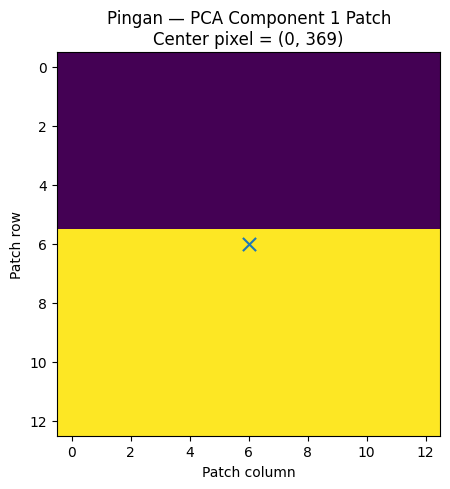

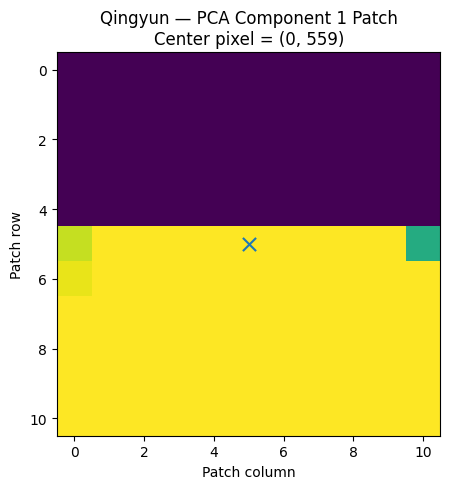

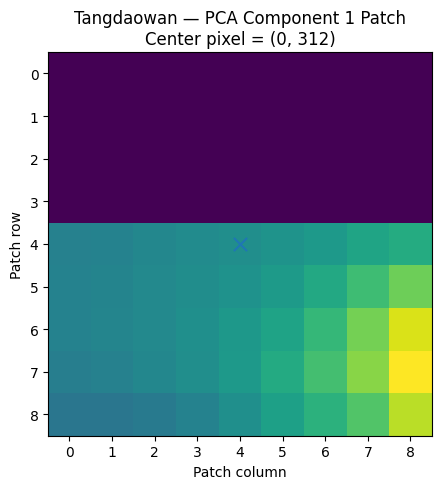

In [46]:
# ============================================================
# CELL 51 — VISUAL PATCH SANITY CHECK
# ============================================================

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    cfg = DATASETS[
        dataset_name
    ]

    cube = np.load(
        CACHE_REGISTRY[
            dataset_name
        ]["cache_path"],
        mmap_mode="r",
        allow_pickle=False
    )

    # Deterministic first frozen training center
    flat_index = int(
        FROZEN_SPLITS[
            dataset_name
        ]["train_indices"][0]
    )

    patch = extract_patch_lazy(
        normalized_cube=cube,
        flat_index=flat_index,
        patch_size=cfg["patch_size"]
    )

    H, W, _ = cfg[
        "cube_shape"
    ]

    row, col = (
        flat_index_to_row_col(
            flat_index,
            H,
            W
        )
    )

    margin = (
        cfg["patch_size"]
        // 2
    )

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(
        patch[:, :, 0]
    )

    plt.scatter(
        [margin],
        [margin],
        marker="x",
        s=90
    )

    plt.title(
        f"{dataset_name} — "
        f"PCA Component 1 Patch\n"
        f"Center pixel = ({row}, {col})"
    )

    plt.xlabel(
        "Patch column"
    )

    plt.ylabel(
        "Patch row"
    )

    plt.tight_layout()

    figure_path = (
        PREPROCESS_AUDIT_DIR /
        f"{dataset_name.lower()}_patch_visual_check.png"
    )

    plt.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    del patch
    del cube

    gc.collect()

In [47]:
# ============================================================
# CELL 52 — RELOAD PATCH MANIFEST AND VERIFY
# ============================================================

with open(
    PATCH_MANIFEST_PATH,
    "r",
    encoding="utf-8"
) as f:

    reloaded_patch_manifest = (
        json.load(f)
    )


manifest_checks = {}

for dataset_name in DATASETS:

    saved = (
        reloaded_patch_manifest[
            "datasets"
        ][dataset_name]
    )

    cfg = DATASETS[
        dataset_name
    ]

    shape_pass = (
        saved["patch_shape"]
        ==
        [
            cfg["patch_size"],
            cfg["patch_size"],
            cfg["pca_components"],
        ]
    )

    split_hash_pass = (
        saved["split_sha256"]
        ==
        cfg["expected_split_hash"]
    )

    equivalence_pass = (
        saved[
            "lazy_reference_equivalence"
        ]
        is True
    )

    cache_hash_pass = (
        saved[
            "normalized_cube_sha256"
        ]
        ==
        CACHE_REGISTRY[
            dataset_name
        ]["metadata"]["cache_sha256"]
    )

    overall = all([
        shape_pass,
        split_hash_pass,
        equivalence_pass,
        cache_hash_pass,
    ])

    manifest_checks[
        dataset_name
    ] = overall

    print(f"\n{dataset_name.upper()}")
    print("-" * 60)

    print(
        "Patch shape     :",
        "PASS"
        if shape_pass
        else "FAIL"
    )

    print(
        "Split SHA-256   :",
        "PASS"
        if split_hash_pass
        else "FAIL"
    )

    print(
        "Cube SHA-256    :",
        "PASS"
        if cache_hash_pass
        else "FAIL"
    )

    print(
        "Lazy equivalence:",
        "PASS"
        if equivalence_pass
        else "FAIL"
    )

    print(
        "STATUS          :",
        "PASS"
        if overall
        else "FAIL"
    )


ALL_PATCH_MANIFEST_PASS = all(
    manifest_checks.values()
)

print()

print("=" * 90)

print(
    "PATCH MANIFEST STATUS:",
    "PASS"
    if ALL_PATCH_MANIFEST_PASS
    else "FAIL"
)

print("=" * 90)


PINGAN
------------------------------------------------------------
Patch shape     : PASS
Split SHA-256   : PASS
Cube SHA-256    : PASS
Lazy equivalence: PASS
STATUS          : PASS

QINGYUN
------------------------------------------------------------
Patch shape     : PASS
Split SHA-256   : PASS
Cube SHA-256    : PASS
Lazy equivalence: PASS
STATUS          : PASS

TANGDAOWAN
------------------------------------------------------------
Patch shape     : PASS
Split SHA-256   : PASS
Cube SHA-256    : PASS
Lazy equivalence: PASS
STATUS          : PASS

PATCH MANIFEST STATUS: PASS


In [48]:
# ============================================================
# CELL 53 — CONSOLIDATED PREPROCESSING SUMMARY
# ============================================================

preprocessing_summary_records = []

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    cfg = DATASETS[dataset_name]

    metadata = CACHE_REGISTRY[
        dataset_name
    ]["metadata"]

    split = FROZEN_SPLITS[
        dataset_name
    ]

    preprocessing_summary_records.append({

        "dataset":
            dataset_name,

        "raw_shape":
            str(tuple(cfg["cube_shape"])),

        "original_bands":
            int(cfg["cube_shape"][2]),

        "pca_components":
            int(cfg["pca_components"]),

        "explained_variance_retained":
            float(
                metadata[
                    "explained_variance_retained"
                ]
            ),

        "pca_solver":
            metadata[
                "pca_solver_selected"
            ],

        "normalization":
            "minmax_scale(axis=1)",

        "cache_dtype":
            metadata[
                "cache_dtype"
            ],

        "patch_size":
            int(cfg["patch_size"]),

        "patch_shape":
            str(
                (
                    cfg["patch_size"],
                    cfg["patch_size"],
                    cfg["pca_components"],
                )
            ),

        "train_centers":
            int(
                len(
                    split["train_indices"]
                )
            ),

        "validation_centers":
            int(
                len(
                    split["val_indices"]
                )
            ),

        "test_centers":
            int(
                len(
                    split["test_indices"]
                )
            ),

        "cache_sha256":
            metadata[
                "cache_sha256"
            ],

        "split_sha256":
            cfg[
                "expected_split_hash"
            ],
    })


PREPROCESSING_SUMMARY_DF = pd.DataFrame(
    preprocessing_summary_records
)


print("=" * 100)
print("NOTEBOOK 02 — CONSOLIDATED PREPROCESSING SUMMARY")
print("=" * 100)

display(
    PREPROCESSING_SUMMARY_DF[
        [
            "dataset",
            "raw_shape",
            "pca_components",
            "explained_variance_retained",
            "patch_shape",
            "train_centers",
            "validation_centers",
            "test_centers",
        ]
    ]
)

print()

NOTEBOOK 02 — CONSOLIDATED PREPROCESSING SUMMARY


,dataset,raw_shape,pca_components,explained_variance_retained,patch_shape,train_centers,validation_centers,test_centers
0,Pingan,"(1230, 1000, 176)",15,0.999918,"(13, 13, 15)",79869,34230,1026838
1,Qingyun,"(880, 1360, 176)",15,0.999896,"(11, 11, 15)",66844,28648,859401
2,Tangdaowan,"(1740, 860, 176)",20,0.999955,"(9, 9, 20)",24760,10612,469917


In [49]:
# ============================================================
# CELL 54 — SAVE NOTEBOOK 02 MASTER AUDIT
# ============================================================

NOTEBOOK02_SUMMARY_CSV = (
    PREPROCESS_AUDIT_DIR /
    "notebook02_preprocessing_summary.csv"
)

NOTEBOOK02_MASTER_JSON = (
    PREPROCESS_AUDIT_DIR /
    "notebook02_master_preprocessing_audit.json"
)

# ------------------------------------------------------------
# Save CSV summary
# ------------------------------------------------------------

PREPROCESSING_SUMMARY_DF.to_csv(
    NOTEBOOK02_SUMMARY_CSV,
    index=False
)


# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

notebook02_environment = {

    "python":
        sys.version,

    "platform":
        platform.platform(),

    "numpy":
        np.__version__,

    "scipy":
        scipy.__version__,

    "sklearn":
        sklearn.__version__,

    "pandas":
        pd.__version__,
}


# ------------------------------------------------------------
# Master preprocessing audit
# ------------------------------------------------------------

notebook02_master_audit = {

    "project":
        "CSE498R LTLC",

    "notebook":
        "02_QUH_Benchmark_Preprocessing_and_Patch_Cache",

    "created_at":
        datetime.now().isoformat(),

    "preprocessing_protocol": {

        "pca_scope":
            "full unlabeled hyperspectral cube",

        "pca_whitening":
            False,

        "normalization":
            "sklearn.preprocessing.minmax_scale(axis=1)",

        "padding":
            "zero spatial padding",

        "patch_extraction":
            "deterministic lazy extraction",

        "augmentation":
            False,
    },

    "frozen_split_gate":
        bool(
            ALL_FROZEN_SPLITS_VALID
        ),

    "cache_artifact_gate":
        bool(
            ALL_CACHE_ARTIFACTS_VALID
        ),

    "patch_audit_gate":
        bool(
            ALL_PATCH_AUDITS_PASS
        ),

    "lazy_equivalence_gate":
        bool(
            ALL_LAZY_EQUIVALENCE_PASS
        ),

    "patch_manifest_gate":
        bool(
            ALL_PATCH_MANIFEST_PASS
        ),

    "datasets": {},

    "environment":
        notebook02_environment,
}


for dataset_name in DATASETS:

    metadata = CACHE_REGISTRY[
        dataset_name
    ]["metadata"]

    notebook02_master_audit[
        "datasets"
    ][dataset_name] = {

        "raw_cube_shape":
            list(
                DATASETS[
                    dataset_name
                ]["cube_shape"]
            ),

        "pca_components":
            int(
                DATASETS[
                    dataset_name
                ]["pca_components"]
            ),

        "patch_size":
            int(
                DATASETS[
                    dataset_name
                ]["patch_size"]
            ),

        "explained_variance_retained":
            float(
                metadata[
                    "explained_variance_retained"
                ]
            ),

        "pca_solver":
            metadata[
                "pca_solver_selected"
            ],

        "normalized_cube_file":
            metadata[
                "cache_file"
            ],

        "normalized_cube_sha256":
            metadata[
                "cache_sha256"
            ],

        "pca_model_file":
            metadata[
                "pca_model_file"
            ],

        "pca_model_sha256":
            metadata[
                "pca_model_sha256"
            ],

        "split_sha256":
            DATASETS[
                dataset_name
            ]["expected_split_hash"],

        "patch_audit_pass":
            bool(
                PATCH_AUDIT_RESULTS[
                    dataset_name
                ]["passed"]
            ),

        "lazy_equivalence_pass":
            bool(
                LAZY_EQUIVALENCE_RESULTS[
                    dataset_name
                ]
            ),
    }


with open(
    NOTEBOOK02_MASTER_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        notebook02_master_audit,
        f,
        indent=2
    )


print("=" * 90)
print("NOTEBOOK 02 MASTER AUDIT SAVED")
print("=" * 90)

print(
    "CSV :",
    NOTEBOOK02_SUMMARY_CSV
)

print(
    "JSON:",
    NOTEBOOK02_MASTER_JSON
)

print()
print("Master preprocessing audit saved successfully.")

NOTEBOOK 02 MASTER AUDIT SAVED
CSV : /content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/notebook02_preprocessing_summary.csv
JSON: /content/drive/MyDrive/CSE498/LTLC/audit/notebook02_preprocessing/notebook02_master_preprocessing_audit.json

Master preprocessing audit saved successfully.


In [50]:
# ============================================================
# CELL 55 — FINAL DISK ARTIFACT VERIFICATION
# ============================================================

FINAL_CACHE_DISK_CHECKS = {}

print("=" * 100)
print("FINAL PREPROCESSING ARTIFACT DISK CHECK")
print("=" * 100)

for dataset_name in [
    "Pingan",
    "Qingyun",
    "Tangdaowan",
]:

    metadata = CACHE_REGISTRY[
        dataset_name
    ]["metadata"]

    cache_path = (
        PCA_CACHE_DIR /
        metadata["cache_file"]
    )

    model_path = (
        PCA_CACHE_DIR /
        metadata["pca_model_file"]
    )

    cache_exists = (
        cache_path.exists()
    )

    model_exists = (
        model_path.exists()
    )

    cache_hash_pass = (
        cache_exists
        and
        sha256_file(cache_path)
        ==
        metadata["cache_sha256"]
    )

    model_hash_pass = (
        model_exists
        and
        sha256_file(model_path)
        ==
        metadata["pca_model_sha256"]
    )

    overall_pass = all([
        cache_exists,
        model_exists,
        cache_hash_pass,
        model_hash_pass,
    ])

    FINAL_CACHE_DISK_CHECKS[
        dataset_name
    ] = overall_pass

    print(f"\n{dataset_name.upper()}")
    print("-" * 65)

    print(
        "Normalized cube exists :",
        "PASS"
        if cache_exists
        else "FAIL"
    )

    print(
        "PCA model exists       :",
        "PASS"
        if model_exists
        else "FAIL"
    )

    print(
        "Cube SHA-256           :",
        "PASS"
        if cache_hash_pass
        else "FAIL"
    )

    print(
        "Model SHA-256          :",
        "PASS"
        if model_hash_pass
        else "FAIL"
    )

    print(
        "STATUS                 :",
        "PASS"
        if overall_pass
        else "FAIL"
    )


ALL_FINAL_DISK_CHECKS_PASS = all(
    FINAL_CACHE_DISK_CHECKS.values()
)

print("\n" + "=" * 100)

print(
    "FINAL DISK ARTIFACT STATUS:",
    "PASS"
    if ALL_FINAL_DISK_CHECKS_PASS
    else "FAIL"
)

print("=" * 100)

FINAL PREPROCESSING ARTIFACT DISK CHECK

PINGAN
-----------------------------------------------------------------
Normalized cube exists : PASS
PCA model exists       : PASS
Cube SHA-256           : PASS
Model SHA-256          : PASS
STATUS                 : PASS

QINGYUN
-----------------------------------------------------------------
Normalized cube exists : PASS
PCA model exists       : PASS
Cube SHA-256           : PASS
Model SHA-256          : PASS
STATUS                 : PASS

TANGDAOWAN
-----------------------------------------------------------------
Normalized cube exists : PASS
PCA model exists       : PASS
Cube SHA-256           : PASS
Model SHA-256          : PASS
STATUS                 : PASS

FINAL DISK ARTIFACT STATUS: PASS


In [51]:
# ============================================================
# CELL 56 — NOTEBOOK 02 FINAL PREPROCESSING GATE
# ============================================================

NOTEBOOK02_GATE_CHECKS = {

    "notebook01_frozen_splits":
        bool(
            ALL_FROZEN_SPLITS_VALID
        ),

    "pingan_preprocessing":
        bool(
            PINGAN_PREPROCESSING_PASS
        ),

    "qingyun_preprocessing":
        bool(
            QINGYUN_PREPROCESSING_PASS
        ),

    "tangdaowan_preprocessing":
        bool(
            TANGDAOWAN_PREPROCESSING_PASS
        ),

    "pingan_cache_reload":
        bool(
            PINGAN_CACHE_RELOAD_PASS
        ),

    "qingyun_cache_reload":
        bool(
            QINGYUN_CACHE_RELOAD_PASS
        ),

    "tangdaowan_cache_reload":
        bool(
            TANGDAOWAN_CACHE_RELOAD_PASS
        ),

    "all_cache_artifacts":
        bool(
            ALL_CACHE_ARTIFACTS_VALID
        ),

    "zero_padding_patch_audits":
        bool(
            ALL_PATCH_AUDITS_PASS
        ),

    "lazy_reference_equivalence":
        bool(
            ALL_LAZY_EQUIVALENCE_PASS
        ),

    "patch_manifest":
        bool(
            ALL_PATCH_MANIFEST_PASS
        ),

    "final_disk_artifacts":
        bool(
            ALL_FINAL_DISK_CHECKS_PASS
        ),
}


print("=" * 105)
print("LTLC NOTEBOOK 02 — FINAL BENCHMARK PREPROCESSING GATE")
print("=" * 105)


for check_name, passed in (
    NOTEBOOK02_GATE_CHECKS.items()
):

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{check_name}"
    )


NOTEBOOK02_GATE_PASS = all(
    NOTEBOOK02_GATE_CHECKS.values()
)


print("=" * 105)

print(
    "GATE 2 FINAL STATUS:",
    "PASS"
    if NOTEBOOK02_GATE_PASS
    else "FAIL"
)


if NOTEBOOK02_GATE_PASS:

    print()
    print(
        "Notebook 02 completed successfully."
    )

    print(
        "Benchmark-compatible PCA, normalization, "
        "padding, and patch extraction are frozen."
    )

    print()
    print(
        "The immutable Notebook 01 split protocol "
        "has been preserved."
    )

    print()
    print(
        "NEXT STAGE:"
    )

    print(
        "HybridSN baseline training and "
        "benchmark reproduction."
    )

else:

    print()
    print(
        "STOP — DO NOT BEGIN MODEL TRAINING."
    )


print("=" * 105)

LTLC NOTEBOOK 02 — FINAL BENCHMARK PREPROCESSING GATE
PASS  | notebook01_frozen_splits
PASS  | pingan_preprocessing
PASS  | qingyun_preprocessing
PASS  | tangdaowan_preprocessing
PASS  | pingan_cache_reload
PASS  | qingyun_cache_reload
PASS  | tangdaowan_cache_reload
PASS  | all_cache_artifacts
PASS  | zero_padding_patch_audits
PASS  | lazy_reference_equivalence
PASS  | patch_manifest
PASS  | final_disk_artifacts
GATE 2 FINAL STATUS: PASS

Notebook 02 completed successfully.
Benchmark-compatible PCA, normalization, padding, and patch extraction are frozen.

The immutable Notebook 01 split protocol has been preserved.

NEXT STAGE:
HybridSN baseline training and benchmark reproduction.
